In [1]:
# ===========================================================================
# CONFIG LOADER  --  edit config.py, NOT this cell.
# Gives you `cfg` (every country knob) and `P` (the standard paths).
# ===========================================================================
import os, sys, importlib.util

# config.py lives in activity/, beside this notebook.
# From activity/ that is simply the current folder; from solutions/ it is next door.
CODE_DIR = os.getcwd()
if not os.path.exists(os.path.join(CODE_DIR, "config.py")):
    CODE_DIR = os.path.abspath(os.path.join(CODE_DIR, "..", "activity"))

_spec = importlib.util.spec_from_file_location("config", os.path.join(CODE_DIR, "config.py"))
cfg = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(cfg)
P = cfg.derive_paths(CODE_DIR)     # creates raw/, data/, output/, logs/ if missing

print(f"[CONFIG] {cfg.COUNTRY} ({cfg.CODE}) | date_str={cfg.DATE_STR} | "
      f"train {cfg.TRAIN_START} -> test {cfg.TEST_START} -> target {cfg.DESIRED_DATE}")


[CONFIG] Jamaica (JM) | date_str=20260806 | train 2015-03-01 -> test 2023-06-01 -> target 2026-06-01


### Nowcasting GDP

**Last edit:** 2026-08-01

## What this script does
This notebook runs the full nowcasting pipeline for Jamaica GDP.
Every country-specific value comes from `config.py` (loaded in the first cell);
the model library lives in `nwcst_helpers.py`. The steps are:

- Uses **LARS** (Least Angle Regression) to identify a strong set of candidate predictors
- Iterates over **plausible covariate sets** (feature combinations) derived from the candidate pool
- Fits each model on the training sample, generates **out-of-sample predictions** on the test sample, and produces GDP nowcasts
- Stores outputs in structured results tables (model performance + predictions by vintage/specification)

## Models included
The toolkit currently estimates and compares:

- **OLS**
- **Ridge (OLS + L2 regularization)**
- **LASSO (L1 regularization)**
- **Elastic Net**
- **Decision Tree**
- **Random Forest**
- **Gradient Boosting Tree**
- **LSTM (Long Short-Term Memory neural network)**

## Additional packkages

Be sure to install:

```bash
pip install tqdm-joblib
```

## Import libraries

In [2]:
# =========================================================
# User settings (edit here as necessary)
# =========================================================

import pandas as pd
from datetime import datetime

# ---------------------------------------------------------
# 0) DATA/METADATA FILE NAMES
# ---------------------------------------------------------
data_file = cfg.DATA_CSV
meta_file = cfg.METADATA_CSV

# ---------------------------------------------------------
# 1) DEFINE TRAIN / TEST WINDOW
# ---------------------------------------------------------
# These dates define the sample splits used for model training and evaluation.
# - Training sample:   [train_start_date, test_start_date)
# - Test sample:       [test_start_date, test_end_date]
train_start_date = cfg.TRAIN_START
test_start_date  = cfg.TEST_START

# Convert to Timestamp for safer comparisons later
train_start_date = pd.to_datetime(train_start_date)
test_start_date  = pd.to_datetime(test_start_date)

# ---------------------------------------------------------
# 2) DEFINE OUT-OF-SAMPLE FORECAST TARGET (LAST DATE / VINTAGE)
# ---------------------------------------------------------
# This is the date for which you want to produce the final nowcast/forecast.
# Use the first day of the month (or the appropriate GDP reference month).
desired_date = pd.to_datetime(cfg.DESIRED_DATE)

# ---------------------------------------------------------
# 3) DEFINE OUTPUT FILENAMES (timestamped)
# ---------------------------------------------------------
# Timestamp output files so each run creates a unique set of results.
# DATE_STR comes from config.py so act9_results reads exactly this run.
date_str = cfg.DATE_STR

forecast_file     = f"{date_str} 3_nwcst Tab fcst.xlsx"   # model forecasts / nowcasts
performance_file  = f"{date_str} 3_nwcst Tab perf.xlsx"   # model performance metrics
outofsample_file  = f"{date_str} 3_nwcst Tab oos.xlsx"    # full OOS prediction panel

# (Optional) If you want to resume / compare against a previous run,
# set last_performance to the filename of the prior performance workbook.
# Example: last_performance = "perf_20251207.xlsx"
last_performance = None

# ---------------------------------------------------------
# 4) MODEL SETTINGS
# ---------------------------------------------------------
# Target GDP series ID
target_variable = "RGDP0000"

# Prediction horizon (vintages) to evaluate:
# - negative values: backcasts (e.g., -1 = one period back)
# - 0: nowcast (current period)
# - positive values: forecasts (e.g., +1 = one period ahead)
lags = list(cfg.LAGS)

# ---------------------------------------------------------
# 5) TARGET MODELS
# ---------------------------------------------------------
# Define models of interest
run = dict(cfg.RUN)

# Parameter: iterations in GBT, DT, RF
_iter_ = cfg.ITER
# Parameter: LSTM n_models and train_episodes
_iter_lstm = cfg.ITER_LSTM
_epoch_lstm = cfg.EPOCH_LSTM

# ---------------------------------------------------------
# 6) BETA13/14 EXTENSIONS  (config.py section 6)
# ---------------------------------------------------------
# The research-branch methods, every one defaulting to OFF. Read once here so
# nothing further down has to reach into cfg for them. With config.py as shipped
# this notebook produces exactly what it produced on 2026-08-01.
_wdecay       = cfg.SAMPLE_WEIGHT_DECAY   # None = unweighted training sample
_seed         = cfg.NWCST_SEED            # None = stochastic trees / LSTM
_fill         = cfg.NWCST_FILL            # "mean" | "ffill"
_scale_lin    = bool(cfg.SCALE_LINEAR)    # StandardScaler around Ridge/ENET/LASSO
_ridge_alphas = list(cfg.RIDGE_ALPHAS)
_max_workers  = cfg.MAX_WORKERS           # None = derive from cpu_count

_shock_feat = bool(cfg.SHOCK_FEATURES)
_winsor_z   = cfg.SHOCK_WINSOR_Z
_break_z    = cfg.SHOCK_BREAK_Z
_min_broken = cfg.SHOCK_MIN_BROKEN

_rolling    = bool(cfg.ROLLING_LARS)
_roll_max   = cfg.ROLLING_MAX_VARS
_cv         = bool(cfg.SELECTION_CV)
_cv_min     = cfg.CV_MIN_TRAIN
_cv_step    = cfg.CV_STEP
_cv_eval    = cfg.CV_EVAL_SIZE
_size_range = tuple(cfg.LARS_SIZE_RANGE)

_loo_dates  = [pd.to_datetime(x) for x in cfg.LOO_SHOCK_DATES]

_on = [n for n, v in [("sample weights", _wdecay), ("seed", _seed),
                      ("ffill", _fill == "ffill"), ("scaled linear", _scale_lin),
                      ("shock features", _shock_feat), ("rolling LARS", _rolling),
                      ("selection CV", _cv), ("LOO shocks", bool(_loo_dates))] if v]
print("[BETA13/14] " + (", ".join(_on) if _on else "all extensions OFF (2026-08-01 behaviour)"))

# =========================================================
# =========================================================
# =========================================================
# Nowcasting pipeline: imports, paths, data loading, and preprocessing
# =========================================================
# This section:
# 1) Imports all required libraries for the nowcasting toolkit (ML + time-series + LSTM)
# 2) Defines local folder paths for raw inputs, processed data, and outputs
# 3) Loads the full dataset and metadata
# 4) Deflates nominal variables using CPI (base year = cfg.CPI_BASE_YEAR average)
# 5) Seasonally adjusts series using trend extraction from seasonal decomposition
# 6) Converts all series to growth rates (percent change)
# 7) Cleans the final modeling dataset and prints library versions for reproducibility
# =========================================================

import os, json, time, warnings, re
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# -----------------------------
# Models / ML utilities
# -----------------------------
from sklearn import linear_model, tree
from sklearn.linear_model import (
    LinearRegression, RidgeCV, ElasticNet, Lasso, Lars
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Optional time-series tools (if used downstream)
import pmdarima as pm

# Deep learning (LSTM nowcasting)
import torch
from nowcast_lstm.LSTM import LSTM

# Statsmodels seasonal adjustment
from statsmodels.tsa.seasonal import seasonal_decompose

# Reduce noisy warnings from some estimators / decomposition
warnings.filterwarnings("ignore", category=UserWarning)

# =========================================================
# Paths
# =========================================================
# Define local project directories (relative to current working directory)
# P was built by the config loader in the first cell, so the folder depth lives in
# config.PROJECT_ROOT only -- moving this notebook never breaks the paths again.
PATH_RAW = P["raw"]                                  # raw inputs (downloads / intermediate CSVs)
PATH_DATA = P["data"]                                # processed modeling tables
# Output folder for model results (forecasts, performance tables)
PATH_OUTPUT = os.path.join(P["output"], date_str)
# In case it is run several times in a day:
# Create folder if it does not exist
os.makedirs(PATH_OUTPUT, exist_ok=True)

print("# =========================================================")
print("Key Directories:")
print(f"Raw inputs: {PATH_RAW}")
print(f"Modeling data: {PATH_DATA}")
print(f"Model outputs: {PATH_OUTPUT}")
print("# =========================================================")

# =========================================================
# Load data and metadata
# =========================================================
# Main modeling dataset (indexed by date)
data = pd.read_csv(
    os.path.join(PATH_DATA, data_file ),
    parse_dates=["date"],
    index_col="date"
)

test_end_date = data[target_variable].dropna().index.max()

# Metadata describing each variable (frequency, nominal/real flags, etc.)
# NOTE: this uses a Windows-style path separator; works on Windows.
# For portability, consider: os.path.join(PATH_DATA, "meta_full.csv")
metadata = pd.read_csv(os.path.join(PATH_DATA, meta_file))

# Key column names and CPI series ID used for deflation
meta_col = "ticket"     # variable identifier column in metadata
cpi = cfg.CPI_TICKER    # CPI series used to deflate nominal variables (country-specific)

# =========================================================
# Deflate nominal variables using CPI (base year: cfg.CPI_BASE_YEAR average)
# =========================================================
# Many series are nominal; deflating them puts everything in real terms.
# We compute a CPI base as the average CPI level in cfg.CPI_BASE_YEAR.
base = data[cpi][data.index.year == cfg.CPI_BASE_YEAR].mean()   # beta11: deflator base

# Identify variables flagged as nominal in metadata
nominal = metadata.loc[metadata["nominal"] == 1][meta_col].values

# Deflate: Real_t = Nominal_t / CPI_t * CPI_base   (corrected: was multiplying)
for column in data.columns:
    if column in nominal:
        data[column] = data[column] / data[cpi] * base    # beta11: divide (deflate) not multiply

# Drop CPI
data.drop(columns=[cpi], inplace=True)
# Drop GDP components
data = data.drop(columns=[col for col in data.columns if 'RGDP' in col and col != 'RGDP0000'])


[BETA13/14] sample weights, seed, ffill, scaled linear, shock features, rolling LARS, selection CV, LOO shocks
# =========================================================
Key Directories:
Raw inputs: c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\raw
Modeling data: c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\data
Model outputs: c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\output\20260806
# =========================================================


In [3]:
# .str accessor lets you use string methods on a Series; .str.lower() converts to lowercase
quarterly  = metadata.loc[metadata["freq"].str.lower().str.contains("q")][meta_col].values
monthly    = metadata.loc[metadata["freq"].str.lower().str.contains("m")][meta_col].values

# Keep only columns with at least 24 non-NaN values; .notna().sum() counts non-missing entries per column
data = data.loc[:, data.notna().sum() >= 24]

# =========================================================
# Seasonal adjustment (only for non-SA variables)
# =========================================================
# Variables with sa==1 in metadata are already seasonally adjusted by the source.
# For all others, subtract only the seasonal component (keeps trend + residual/shocks).
already_sa = metadata.loc[metadata["sa"]==1][meta_col].values   # sa=1 means already seasonally adjusted
non_sa = metadata.loc[metadata["sa"] == 0, meta_col].values

_season_filter = cfg.SEASONAL_FILTER   # 0 = classical, 1 = X-13ARIMA-SEATS

if _season_filter == 0 :
    for column in data.columns:
        if column in already_sa:
            continue   # 'continue' skips the rest of the loop body and moves to the next column
        series = data[column].dropna()   # remove NaN before decomposing (seasonal_decompose requires it)
        if column in quarterly:
            # period=4: quarterly series has 4 seasons per year
            decomp = seasonal_decompose(series, model='additive', extrapolate_trend='freq', period=4)
            data[column] = data[column] - decomp.seasonal   # subtract seasonal component to remove seasonality
        else :
            # period=12: monthly series has 12 seasons per year
            decomp = seasonal_decompose(series, model='additive', extrapolate_trend='freq', period=12)
            data[column] = data[column] - decomp.seasonal

# X-13ARIMA-SEATS instead of classical seasonal_decompose. The US Census
# Bureau's production method: it models the series (ARIMA + outliers) before
# splitting it, and handles the concurrent-vs-final seasonal factor distinction
# that matters when you are adjusting the most recent quarter in real time.
#
# statsmodels only WRAPS X-13 -- the work is done by an external executable that
# is shelled out to once per series. Two consequences:
#   * it must be installed. cfg.X13_PATH = None looks for it on PATH; the binary
#     lives in envs/nwcst/Library/bin, so activating nwcst is enough.
#   * it is much slower than the classical route. Expect minutes, not seconds.
# Any series X-13 refuses (too short, monotonic, degenerate) falls back to the
# classical decomposition, and the counts are printed -- so a run that quietly
# adjusted nothing the Census way is visible rather than assumed.
elif _season_filter == 1 :
    import os, shutil, time
    from statsmodels.tsa.x13 import x13_arima_analysis

    # statsmodels wants the DIRECTORY holding the executable, not the executable
    # itself. It does try to strip a filename, but only when the path ends with a
    # lower-case binary name -- and shutil.which() returns "x13as.EXE" on Windows,
    # which slips past that check and yields a bogus join. So resolve to the
    # directory here and hand it that.
    _x13_found = cfg.X13_PATH or shutil.which("x13as") or shutil.which("x13as_ascii")
    if _x13_found and os.path.isfile(_x13_found):
        X13_BINARY = os.path.dirname(_x13_found)
    else:
        X13_BINARY = _x13_found          # already a directory, or None
    if X13_BINARY is None:
        print("[X-13] no x13as binary found on PATH and cfg.X13_PATH is None.\n"
              "       EVERY series will fall back to classical seasonal_decompose.\n"
              "       Install X-13ARIMA-SEATS, or set SEASONAL_FILTER = 0 to say so explicitly.")
    else:
        print(f"[X-13] using binary in {X13_BINARY}")

    _n_x13 = _n_fallback = _n_skipped = 0
    _t0 = time.time()

    for column in list(data.columns):
        if column not in non_sa:
            continue
        series = data[column].dropna()
        if len(series) < 36:  # X-13 needs >= 36 obs to estimate seasonality
            _n_skipped += 1
            continue
        period = 4 if column in quarterly else 12
        try:
            if X13_BINARY is None:
                raise RuntimeError("no X-13 binary")
            # X-13 requires a PeriodIndex with quarterly/monthly frequency
            freq_str = "Q" if period == 4 else "M"
            s_idx = series.copy()
            s_idx.index = pd.PeriodIndex(s_idx.index, freq=freq_str)
            result = x13_arima_analysis(
                s_idx,
                x12path=X13_BINARY,
                prefer_x13=True,
                outlier=True,
                print_stdout=False,
            )
            sa = result.seasadj
            sa.index = series.index  # restore DatetimeIndex
            # Replace in `data` (preserving the NaN positions outside `series`)
            data[column] = sa.reindex(data[column].index)
            _n_x13 += 1
        except Exception:
            # Fall back to classical seasonal_decompose if X-13 fails
            try:
                decomp = seasonal_decompose(
                    series, model="additive",
                    extrapolate_trend="freq", period=period,
                )
                data[column] = data[column] - decomp.seasonal
                _n_fallback += 1
            except Exception:
                pass  # leave unadjusted

    print(f"Seasonal adjustment: {_n_x13} series by X-13, {_n_fallback} by classical "
          f"fallback, {_n_skipped} too short to adjust ({time.time() - _t0:.0f}s).")

# =========================================================
# Convert levels to growth rates (percent change)
# =========================================================
# Quarterly series: quarter-over-quarter growth rate
# All other series: default percent change at their observed frequency
for column in data.columns:
    if column in quarterly:
        # Get non-NaN values with their original index
        non_nan = data[column].dropna()
        
        # Calculate percent change on non-NaN values only
        pct_change_values = non_nan.pct_change(periods=1, fill_method=None) * 100
        
        # Create a new series filled with NaN, then update with calculated values
        result = pd.Series(np.nan, index=data.index)
        result.loc[pct_change_values.index] = pct_change_values
        
        data[column] = result
    else:
        # Store original NaN mask
        original_was_nan = data[column].isna()
        
        # For monthly/weekly/daily, calculate normally
        pct_change_values = data[column].pct_change(periods=1, fill_method=None) * 100
        
        # Set to NaN where previous value was NaN OR current original value was NaN
        prev_was_nan = data[column].shift(1).isna()
        pct_change_values[prev_was_nan | original_was_nan] = np.nan
        
        data[column] = pct_change_values

data.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================================================
# Drop columns in quarterly with more than 75% missing values
# =========================================================
for column in [ col for col in data.columns if col not in quarterly ] :
    missing_pct = data[data.index<=test_start_date][column].isna().sum() / len(data[data.index<=test_start_date][column])
    if missing_pct > 0.75:
        data.drop(column, axis=1, inplace=True)


# =========================================================
# Final cleaning
# =========================================================
# Replace infinities created by pct_change with NaN
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop CPI from predictor set (used only for deflation)
#data.drop(cpi, axis=1, inplace=True)

# ~ negates a boolean Series; data[condition] filters rows where condition is True
data = data[~(data.index < train_start_date)].reset_index(drop=False)
# .reset_index(drop=False) moves the date index back to a regular column
data = data.set_index("date").dropna(how="all", axis=0)   # drop rows that are entirely NaN

# pd.to_numeric(..., errors='coerce') converts to number; non-numeric values become NaN
metadata["months_lag"] = (
    pd.to_numeric(metadata["months_lag"], errors="coerce")
      .fillna(1)      # replace any NaN lags with 1 (safe default)
      .astype(int)    # .astype(int) casts the Series to integer dtype
)

# Drop those columns
data = data.drop(columns=[col for col in data.columns if 'RGDP' in col and col != 'RGDP0000'])
for col in data.columns :
    last = data[col].dropna().index.max().year   # find the most recent year with data for this column
    if last < 2024 :
        data.drop(col, axis=1, inplace=True)   # remove columns that stopped updating before 2024

def deduplicate_correlated(df, threshold=0.85, target=target_variable,
                           metadata=metadata, meta_col=meta_col):
    """Drop one variable from each highly-correlated pair.
    Priority: (1) keep aggregate tickets (numeric suffix % 100 == 0);
              (2) keep the variable with more non-null observations.
    """
    import re

    def _is_agg(ticket):
        nums = re.findall(r'\d+', str(ticket))
        return bool(nums) and int(nums[-1]) % 100 == 0

    agg_set = set(metadata.loc[metadata[meta_col].apply(_is_agg), meta_col])

    X   = df.drop(columns=[target])
    obs = X.notna().sum()
    corr  = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    to_drop = set()
    for col in upper.columns:
        if col in to_drop:
            continue
        peers = upper.index[upper[col] > threshold].tolist()
        for peer in peers:
            if peer in to_drop:
                continue
            col_agg  = col  in agg_set
            peer_agg = peer in agg_set
            if col_agg and not peer_agg:
                to_drop.add(peer)
            elif peer_agg and not col_agg:
                to_drop.add(col)
                break
            elif obs[col] >= obs[peer]:
                to_drop.add(peer)
            else:
                to_drop.add(col)
                break

    kept = [c for c in df.columns if c not in to_drop]
    print(f"Removed {len(df.columns) - len(kept)} correlated variables "
          f"(|r| > {threshold}). {len(kept)} remain.")
    return df[kept]

data = deduplicate_correlated(data, threshold=0.98)

# Drop high-publication lag series
tickets_to_keep = metadata[metadata.months_lag <= 5]['ticket'].tolist()

# Keep only these columns (that exist in data)
data = data[[ col for col in data.columns if col in tickets_to_keep or "RGDP" in col ]]

data.to_csv(os.path.join(PATH_OUTPUT, "data_processed.csv"), index=True)
metadata = metadata[metadata.ticket.isin(data.columns)]
metadata.to_csv(os.path.join(PATH_OUTPUT, "meta_processed.csv"), index=True)
# =========================================================
# Reproducibility: print core library versions
# =========================================================
print("================== Library Versions =================")
import sklearn, numpy, pandas
print("scikit-learn:", sklearn.__version__)
print("numpy:", numpy.__version__)
print("pandas:", pandas.__version__)


# Data dimensions (observations and variables)
print("Data dimensions:", data.shape)
print(f"Training dates: {train_start_date.strftime('%Y-%m-%d')} to {(test_start_date - pd.DateOffset(days=1)).strftime('%Y-%m-%d')}")
T1 = data[data.index < test_start_date].shape[0]
T2 = data[(data.index >= test_start_date) & (data.index <= test_end_date)].shape[0]
print(f"Training periods: {T1} ({T1/(T1+T2) :.2%})")
print(f"Testing dates: {test_start_date.strftime('%Y-%m-%d')} to {test_end_date.strftime('%Y-%m-%d')}")
print(f"Testing periods: {T2} ({T2/(T1+T2) :.2%})")

Removed 156 correlated variables (|r| > 0.98). 717 remain.
================== Library Versions =================
scikit-learn: 1.8.0
numpy: 2.4.1
pandas: 2.3.3
Data dimensions: (137, 649)
Training dates: 2015-03-01 to 2023-05-31
Training periods: 99 (74.44%)
Testing dates: 2023-06-01 to 2026-03-01
Testing periods: 34 (25.56%)


Visualize variables

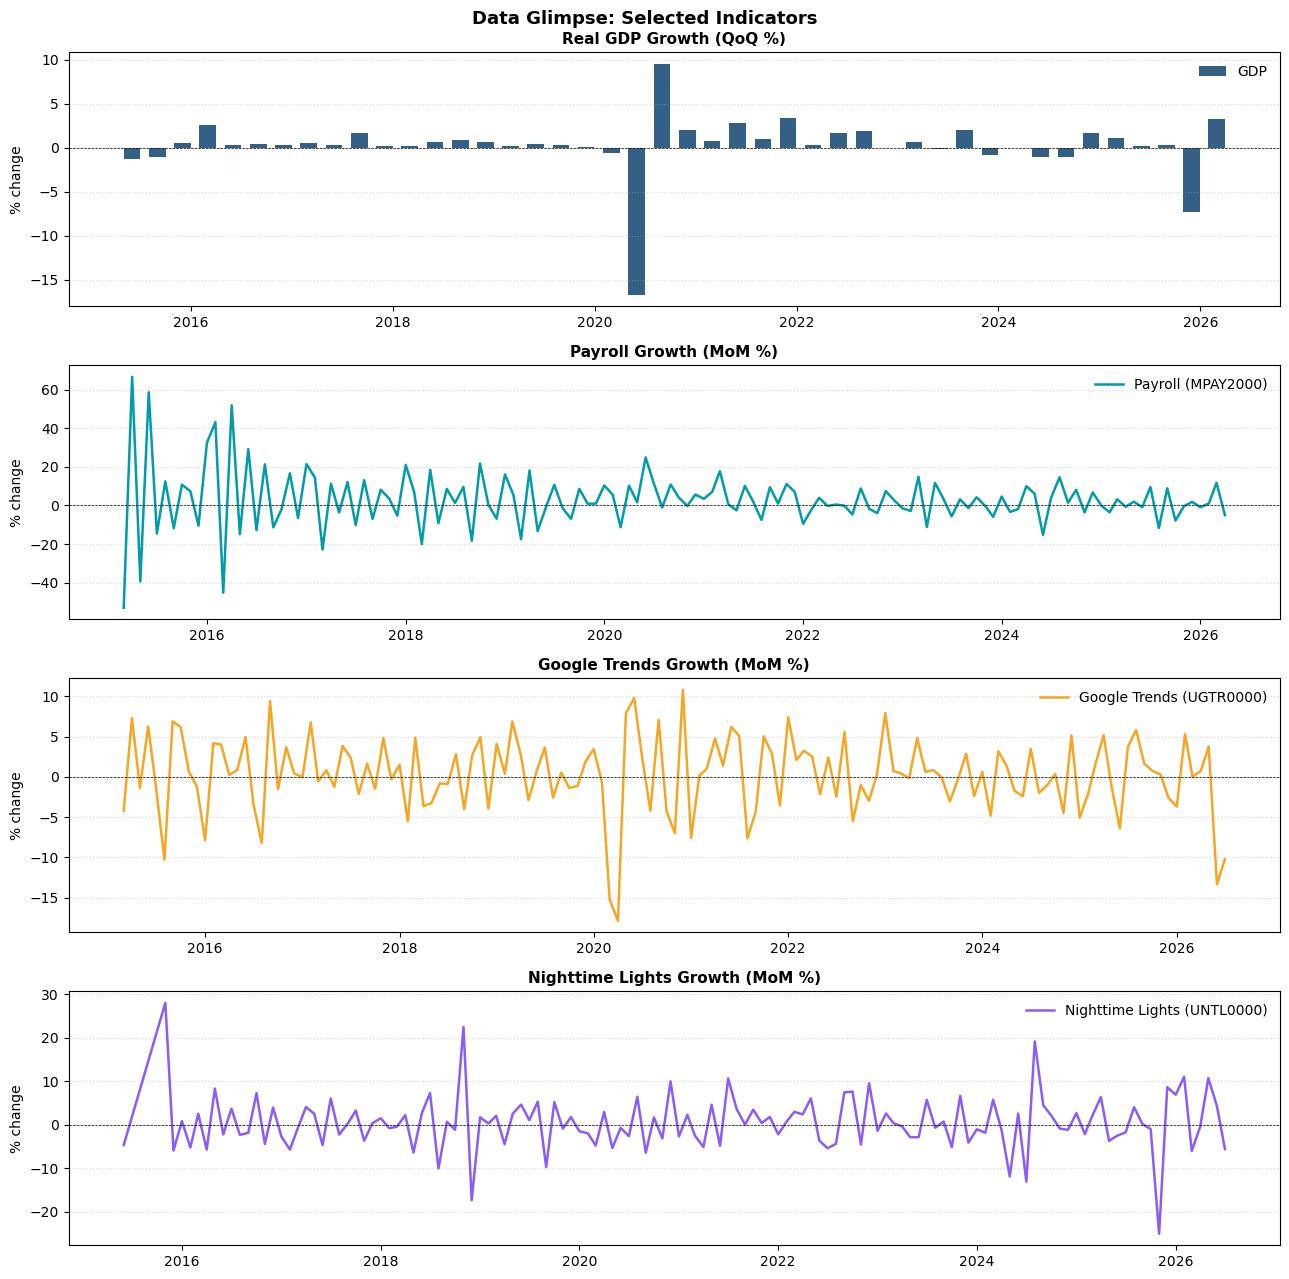

In [4]:
# =========================================================
# Data glimpse: GDP plus a few high-frequency indicators.
# The tickers below are the ones we like to show for Jamaica. Any that did not
# survive the cleaning above (or do not exist for another COUNTRY) are simply
# skipped, so switching country degrades the figure instead of raising KeyError.
# =========================================================
WANTED = [
    ('RGDP0000', 'Real GDP Growth (QoQ %)',              'GDP',                        '#003865', 'bar'),
    ('MPAY2000', 'Payroll Growth (MoM %)',               'Payroll (MPAY2000)',         '#009CA7', 'line'),
    ('UGTR0000', 'Google Trends Growth (MoM %)',         'Google Trends (UGTR0000)',   '#F5A623', 'line'),
    ('UNTL0000', 'Nighttime Lights Growth (MoM %)',      'Nighttime Lights (UNTL0000)','#8B5CF6', 'line'),
]
panels = [p for p in WANTED if p[0] in data.columns]
missing = [p[0] for p in WANTED if p[0] not in data.columns]
if missing:
    print(f"Not plotted (absent from data): {', '.join(missing)}")

fig, axes = plt.subplots(len(panels), 1, figsize=(13, 3.25 * len(panels)), sharex=False)
axes = np.atleast_1d(axes)

for ax, (ticker, title, label, color, kind) in zip(axes, panels):
    s = data[ticker].dropna()
    if kind == 'bar':
        ax.bar(s.index, s, width=60, color=color, alpha=0.8, label=label)
    else:
        ax.plot(s.index, s, color=color, linewidth=1.8, label=label)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(title, fontsize=11, weight='bold')
    ax.set_ylabel('% change')
    ax.legend(frameon=False)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

fig.suptitle('Data Glimpse: Selected Indicators', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(f"{PATH_OUTPUT}/{date_str} 3_nwcst Fig vars_trans.png", dpi=300, bbox_inches='tight')
plt.show()


## Functions

In [5]:
# ===========================================================================
# The model library lives in nwcst_helpers.py, beside this notebook, so this
# notebook stays a thin orchestrator. joblib/loky workers re-import the module,
# so its folder must be importable -- hence the sys.path insert.
# ===========================================================================
import sys, os
for _p in (os.getcwd(), CODE_DIR):          # CODE_DIR: works from solutions/ too
    if _p not in sys.path:
        sys.path.insert(0, _p)

import nwcst_helpers
from nwcst_helpers import *   # estimate_factors, lars_variable_ranking, gen_lagged_data,
                              # flatten_data, mean_fill_dataset, lagged_target,
                              # perform_tab, forecast_table, and fit_/predict_/oos_
                              # for ols, olsr, enet, lasso, dt, rf, gbt, lstm


## Pre-Selection

Pre-selected shape (quarterly): (45, 607)
LARS ranked 99 variables.
Number of CV folds: 13
Benchmark CV MSE: 17.9374
Sizes evaluated: 95, beating benchmark: 22


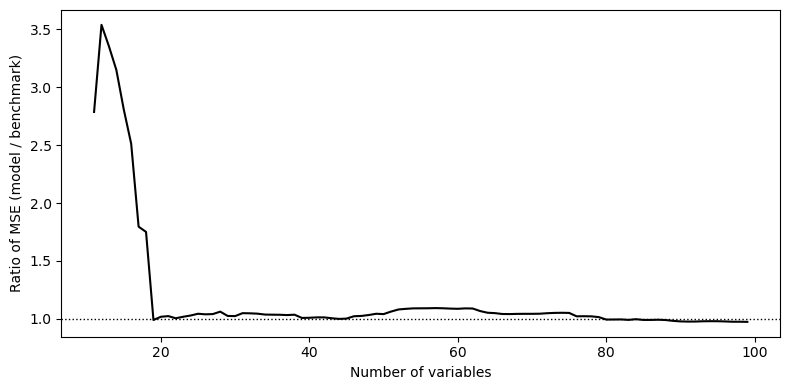

Total specifications selected: 22. 
 Best-RMSE selected variables 99 out of 648
[Rolling LARS] test dates: 11 (2023-07-01 -> 2026-01-01)
[Rolling LARS] 11 dates ranked; top-5 at the last date: ['XBOP3439', 'XBOP3210', 'XBOP3475', 'XBOP3438', 'XIMP0002']
Computing shock features for 41 LARS-selected monthly variables
After augmentation: best spec has 181 features
Added SHOK0000. Shock quarters flagged: 1
Distribution of frequencies in LARS selection:
count    22.000000
mean     17.678753
std       0.150916
min      17.473047
25%      17.540568
50%      17.693476
75%      17.799509
max      17.934702
Name: rmse, dtype: float64


,series,ticket,description,description 2,freq,first_date,last_date,No Obs,months_lag,nominal,sa,unstructured,type,agg_method,file_name
7,bank_loans_central_gvt_time,MLOA2003,Commercial Bank Loans (by customer): Central G...,NaN,MS,1/1/2000,5/1/2026,317,3,NaN,0,0,M,mean,boj_bank_loans_bycustomer.csv
16,bank_loans_local_gvt_time,MLOA3003,Commercial Bank Loans (by customer): Local Gov...,NaN,MS,1/1/2000,5/1/2026,317,3,NaN,0,0,M,mean,boj_bank_loans_bycustomer.csv
22,bank_loans_other_gvt_entities_demand,MLOA4001,Commercial Bank Loans (by customer): Other Gov...,NaN,MS,1/1/2000,5/1/2026,317,3,NaN,0,0,M,mean,boj_bank_loans_bycustomer.csv
23,bank_loans_other_gvt_entities_savings,MLOA4002,Commercial Bank Loans (by customer): Other Gov...,NaN,MS,1/1/2000,5/1/2026,317,3,NaN,0,0,M,mean,boj_bank_loans_bycustomer.csv
33,bank_loans_specified_and_other_financial_insti...,MLOA7003,Commercial Bank Loans (by customer): Specified...,NaN,MS,1/1/2000,5/1/2026,317,3,NaN,0,0,M,mean,boj_bank_loans_bycustomer.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752,bank_loans_specified_and_other_financial_insti...,MLOA7003R,Commercial Bank Loans (by customer): Specified...,NaN,MS,1/1/2000,5/1/2026,317,3,NaN,0,0,M,mean,boj_bank_loans_bycustomer.csv
753,demand_dep_fx_rate,MFXR0200R,FX Deposit Rates: Demand Deposits (quarterly r...,NaN,MS,4/1/2000,5/1/2026,314,3,0.0,0,0,M,mean,boj_deposit_rates_fx.csv
754,bank_loans_central_gvt_time,MLOA2003R,Commercial Bank Loans (by customer): Central G...,NaN,MS,1/1/2000,5/1/2026,317,3,NaN,0,0,M,mean,boj_bank_loans_bycustomer.csv
755,bank_loans_transport_storage_communication_tra...,MLOA9701R,"Commercial Bank Loans (by sector): Transport, ...",NaN,MS,4/1/1986,5/1/2026,480,3,NaN,0,0,M,mean,boj_bank_loans_bysector.csv


In [6]:
import warnings
warnings.filterwarnings('ignore')

# =========================================================
# LARS PRE-SELECTION
# =========================================================
# Two paths, chosen in config.py section 6:
#
#   SELECTION_CV = 0  (default)  One train/test split. The benchmark is a PCA+OLS
#                                regression on ALL variables; each LARS subset
#                                size is scored against it. Fast, and what every
#                                stored output/<date>/ run used.
#   SELECTION_CV = 1             Expanding-window cross-validation. Each subset
#                                size is scored over many folds instead of one
#                                split, so the choice of K is far less dependent
#                                on which quarters happen to land in the test
#                                window. Slower, and it changes K.
#
# Orthogonally, ROLLING_LARS = 1 re-ranks the candidate pool at EVERY test
# quarter using only data strictly before it, and the nowcasting loop then swaps
# in that quarter's top-K. Without it a single ranking, computed once over the
# whole sample, is used at every test date -- which quietly lets the test period
# inform which variables were chosen.
#
# Steps: 1) Prepare df; 2) Estimate benchmark; 3) LARS Estimation; 4) Best-variables
# ---------------------------------------------
# 1. Preparation: LARS cannot handle Missing Values or Mixed-Data
factors = cfg.LARS_FACTORS

# Aggregate according to methods described in metadata
try :
    agg_map = metadata.set_index('ticket')['agg_method'].to_dict()
    agg_funcs = {
        col: (agg_map[col] if agg_map[col] in ['mean', 'last', 'sum'] else 'mean')
        for col in data.columns if col in agg_map
    }
    pre_selected = data.resample('QS').agg(agg_funcs)
except :
    pre_selected = data.resample('QS').mean()


pre_selected.index = pd.to_datetime(pre_selected.index)
pre_selected = pre_selected.dropna(how="all", axis=1)
pre_selected = pre_selected.loc[:, pre_selected.isnull().mean() <= 0.75]

if not _cv:
    # =====================================================================
    # PATH A -- single train/test split (default; unchanged since 2026-08-01)
    # =====================================================================

    # Mean-fill predictors only -- leave target_variable as NaN so we can
    # identify quarters without observed GDP and drop them from training.
    predictors = [c for c in pre_selected.columns if c != target_variable]
    pre_selected[predictors] = pre_selected[predictors].fillna(
        pre_selected[predictors].mean(numeric_only=True)
    )

    # data cannot include periods beyond the GDP we observe
    last_gdp = data[target_variable].dropna()
    last_gdp = last_gdp.index.max()
    pre_selected = pre_selected[pre_selected.index <= last_gdp]
    pre_selected.dropna(subset=[target_variable], inplace=True)
    del last_gdp

    # ---------------------------------------------
    # 2. Benchmark RMSE
    # ---------------------------------------------
    # Split raw data first
    X_raw = pre_selected.drop(target_variable, axis=1)
    y_all = pre_selected[[target_variable]]

    X_train_raw = X_raw[X_raw.index <  pd.to_datetime(test_start_date)]
    X_test_raw  = X_raw[X_raw.index >= pd.to_datetime(test_start_date)]
    y_train     = y_all[y_all.index <  pd.to_datetime(test_start_date)]
    y_test      = y_all[y_all.index >= pd.to_datetime(test_start_date)]

    # Drop quarters where GDP was not observed (NaN target = no real observation)
    obs_mask    = y_train[target_variable].notna()
    y_train     = y_train[obs_mask]
    X_train_raw = X_train_raw[obs_mask]

    # Fit scaler on train only, transform both
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), index=X_train_raw.index)
    X_test_scaled  = pd.DataFrame(scaler.transform(X_test_raw),      index=X_test_raw.index)

    # Fit PCA on train only, transform both
    pca = PCA(n_components=factors)
    X_train = pd.DataFrame(pca.fit_transform(X_train_scaled), index=X_train_raw.index)
    X_test  = pd.DataFrame(pca.transform(X_test_scaled),      index=X_test_raw.index)
    X_train.columns = [f"PC_{i}" for i in range(factors)]
    X_test.columns  = [f"PC_{i}" for i in range(factors)]

    benchmark_model = LinearRegression()
    benchmark_model.fit(X_train, y_train)
    print(f"Training on {len(y_train)} observed GDP quarters")

    y_pred = benchmark_model.predict(X_test).ravel()
    y_true = y_test.values.ravel()

    # Naive baseline: always predict the training-period mean
    naive_pred = float(y_train[target_variable].mean())
    naive_rmse = float(np.sqrt(np.mean((y_true - naive_pred) ** 2)))

    benchmark = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))  # RMSE

    print(f"OLS benchmark RMSE : {benchmark:.4f}")

    # ---------------------------------------------
    # 3. LARS Estimation
    # ---------------------------------------------
    pre_train = pre_selected[pre_selected.index <  test_start_date]
    pre_test  = pre_selected[pre_selected.index >= test_start_date]

    # Estimate LARS over a range of variables included in the estimation
    # Returns RMSE and variable choice
    d = []
    for size in range(_size_range[0], _size_range[1]) :
        selection, rmse = lars_variable_ranking(pre_train, target=target_variable, max_vars=size+1, test = pre_test, factors = factors)
        b = {
            "size" : size+1 ,
            "selected_vars" : selection ,
            "rmse" : rmse
        }
        d.append(b)
    d = pd.DataFrame(d)
    d.set_index('size', inplace=True)

    d['ratio'] = d['rmse']/benchmark

    # ---------------------------------------------
    # 4. Best models: define top models and add them to specification list
    # ---------------------------------------------
    # Best threshold is 1: where models outperform non-selected OLS
    threshold = 1
    d['ratio'].plot(color='black')
    plt.axhline(y=threshold, color='black', linestyle=':', linewidth=1)
    plt.ylabel("Ratio of RMSE")
    plt.xlabel("Number of variables")
    plt.legend().set_visible(False)
    plt.savefig(f"{PATH_OUTPUT}/{date_str} 3_nwcst Fig lars_ratio.png", dpi=300, bbox_inches='tight')
    plt.show()

    print(f"OLS benchmark RMSE : {benchmark:.4f}")
    print(f"LARS min RMSE : {d['rmse'].min():.4f}")

    # Keep specifications where rmse is below the threshold: these are the top models
    spec_list = d[d['ratio']<threshold]
    spec_list['selected_vars'] = spec_list['selected_vars'].apply(lambda x: ' '.join(x))

else:
    # =====================================================================
    # PATH B -- expanding-window cross-validation  (beta12/beta14a)
    # =====================================================================
    # Rank ONCE over the whole quarterly panel, then score each prefix of that
    # ranking over many expanding-window folds. The score is a mean MSE across
    # folds rather than a single split's RMSE, so `benchmark` and `rmse` below
    # are MSEs -- comparable to each other, not to PATH A's numbers.
    pre_selected = pre_selected.ffill().bfill()
    pre_selected = pre_selected[pre_selected.index <= data[target_variable].dropna().index.max()]
    print(f"Pre-selected shape (quarterly): {pre_selected.shape}")

    FIXED_SIZE = min(_roll_max, pre_selected.shape[1] - 1)
    top_vars, _ = lars_variable_ranking(pre_selected, target=target_variable,
                                        max_vars=FIXED_SIZE, test=None, factors=factors)
    print(f"LARS ranked {len(top_vars)} variables.")

    n           = len(pre_selected)
    fold_starts = list(range(_cv_min, n - _cv_eval, _cv_step))
    print(f"Number of CV folds: {len(fold_starts)}")

    def _cv_score(columns):
        """Mean MSE over the expanding-window folds for one column subset.
        columns=None scores the PCA+OLS benchmark on every available variable."""
        fold_mses = []
        for fs in fold_starts:
            fold_train = pre_selected.iloc[:fs]
            fold_val   = pre_selected.iloc[fs:fs + _cv_eval]
            y_tr = fold_train[target_variable].dropna()
            y_vl = fold_val[target_variable].dropna()
            if len(y_tr) < 5 or len(y_vl) < 1:
                continue
            cols = columns if columns is not None else [
                c for c in pre_selected.columns if c != target_variable]
            X_tr = fold_train[cols].loc[y_tr.index].ffill().bfill()
            X_vl = fold_val[cols].loc[y_vl.index].ffill().bfill()
            sc    = StandardScaler()
            ncomp = min(factors, len(cols), len(y_tr) - 1)
            X_tr_s = sc.fit_transform(X_tr)
            pca_f  = PCA(n_components=ncomp).fit(X_tr_s)
            m = LinearRegression().fit(pca_f.transform(X_tr_s), y_tr)
            fold_mses.append(np.mean((y_vl.values - m.predict(pca_f.transform(sc.transform(X_vl)))) ** 2))
        return float(np.mean(fold_mses)) if fold_mses else np.nan

    benchmark = _cv_score(None)
    print(f"Benchmark CV MSE: {benchmark:.4f}")

    results = []
    for size in range(5, FIXED_SIZE + 1):
        top_k     = top_vars[:size]
        available = [v for v in top_k if v in pre_selected.columns]
        if len(available) < 2:
            continue
        avg_mse = _cv_score(available)
        results.append({'size': size, 'selected_vars': ' '.join(top_k),
                        'rmse': avg_mse, 'ratio': avg_mse / benchmark})

    d = pd.DataFrame(results).set_index('size', drop=False)
    print(f"Sizes evaluated: {len(d)}, beating benchmark: {(d['ratio'] < 1).sum()}")

    fig, ax = plt.subplots(figsize=(8, 4))
    d[d['size'] > 10]['ratio'].plot(ax=ax, color='black')
    ax.axhline(y=1, color='black', linestyle=':', linewidth=1)
    ax.set_ylabel("Ratio of MSE (model / benchmark)")
    ax.set_xlabel("Number of variables")
    ax.legend().set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{PATH_OUTPUT}/{date_str} 3_nwcst Fig lars_ratio.png", dpi=300, bbox_inches='tight')
    plt.show()

    spec_list = d[d['ratio'] < 1].drop(columns=['size']).copy()

# -------------------------------------------------------------------------
# Shared tail
# -------------------------------------------------------------------------
if len(spec_list) == 0:
    raise RuntimeError(
        "No LARS specification beat the benchmark (ratio < 1). Widen "
        "LARS_SIZE_RANGE, or check that the target series is populated.")

# Variables included in best-RMSE LARS:
top_vars = spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars'].split(" ")
print(f"Total specifications selected: {len(spec_list)}. \n Best-RMSE selected variables {len(top_vars)} out of {len(data.columns)-1}")

# K = how many variables this spec takes off the top of the ranking. The index
# already is that number; naming it as a column keeps it through cell 12's
# assign/concat chain, where the nowcasting loop and the watchlist both need it.
spec_list['K'] = spec_list.index.astype(int)
spec_list['rolling_enabled'] = 0

# ---------------------------------------------
# Rolling LARS -- re-rank at every test quarter
# ---------------------------------------------
rolling_selections = {}      # {Timestamp: [ranked vars]}; empty = feature off
if _rolling:
    _test_dates = [t for t in pre_selected.index
                   if t >= pd.Timestamp(test_start_date) and t <= pre_selected.index.max()]
    print(f"[Rolling LARS] test dates: {len(_test_dates)} "
          f"({_test_dates[0].date()} -> {_test_dates[-1].date()})")

    for _t in _test_dates:
        _train_slice = pre_selected[pre_selected.index < _t]
        if len(_train_slice) < _cv_min:
            rolling_selections[_t] = []
            continue
        _ranked, _ = lars_variable_ranking(
            _train_slice, target=target_variable,
            max_vars=min(_roll_max, _train_slice.shape[1] - 1),
            test=None, factors=factors)
        rolling_selections[_t] = list(_ranked)

    print(f"[Rolling LARS] {len(rolling_selections)} dates ranked; "
          f"top-5 at the last date: {rolling_selections[_test_dates[-1]][:5]}")

    # Each spec keeps its K but now points at the ranking as of the LAST test
    # date. The worker looks up rolling_selections[t][:K] per quarter, so this
    # value is only what gets displayed and what OOS uses.
    spec_list['selected_vars'] = spec_list['K'].apply(
        lambda k: ' '.join(rolling_selections[_test_dates[-1]][:int(k)]))
    spec_list['rolling_enabled'] = 1
    top_vars = spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars'].split(' ')

# ---------------------------------------------
# Shock features
# ---------------------------------------------
# A quarterly average hides a collapse that lasted six weeks. For every
# LARS-selected MONTHLY series X we therefore add two derived series:
#   X + "N"  quarterly MINimum  -- how bad did it get
#   X + "R"  quarterly RANGE    -- how violently did it move
# The one-letter suffix keeps the project's 8-character ticket convention, so
# gen_lagged_data() can still find each one's publication lag in `metadata`.
# SHOK0000 then flags quarters where many of those minima break down together.
if _shock_feat:
    all_base_vars = set()
    for _, row in spec_list.iterrows():
        all_base_vars.update(row['selected_vars'].split())
    base_monthly_vars = [v for v in all_base_vars if v in monthly]
    print(f"Computing shock features for {len(base_monthly_vars)} LARS-selected monthly variables")

    if base_monthly_vars:
        md = data[base_monthly_vars]

        qmin_full = md.resample('QS').min().reindex(data.index, method='ffill')
        qmin_full.columns = [c + 'N' for c in qmin_full.columns]

        qrange_full = (md.resample('QS').max() - md.resample('QS').min()).reindex(data.index, method='ffill')
        qrange_full.columns = [c + 'R' for c in qrange_full.columns]

        data = pd.concat([data, qmin_full, qrange_full], axis=1)

        # Synthesize metadata rows so gen_lagged_data() knows publication lags
        aug_meta_rows = []
        for col in list(qmin_full.columns) + list(qrange_full.columns):
            parent_row = metadata[metadata['ticket'] == col[:-1]]   # strip 'N'/'R'
            if len(parent_row) > 0:
                new_row = parent_row.iloc[0].copy()
                new_row['ticket'] = col
                new_row['description'] = str(new_row.get('description', col)) + (
                    ' (quarterly min)' if col.endswith('N') else ' (quarterly range)')
                aug_meta_rows.append(new_row)
        if aug_meta_rows:
            metadata = pd.concat([metadata, pd.DataFrame(aug_meta_rows)], ignore_index=True)

        # Expand each spec's selected_vars: base + baseN + baseR
        def _augment_spec_vars(vars_str):
            out = []
            for v in vars_str.split():
                out.append(v)
                if v in monthly:
                    out.append(v + 'N')
                    out.append(v + 'R')
            return ' '.join(out)

        spec_list['selected_vars'] = spec_list['selected_vars'].apply(_augment_spec_vars)
        print(f"After augmentation: best spec has "
              f"{len(spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars'].split(' '))} features")

        # Binary shock flag: at least SHOCK_MIN_BROKEN quarterly minima sit below
        # SHOCK_BREAK_Z standard deviations of their TRAINING-period distribution
        # at the same time. Standardising on the training window only keeps the
        # flag out-of-sample; on Jamaica it picks out COVID 2020Q2 and Melissa 2025Q4.
        _train_mask = qmin_full.index < test_start_date
        _mu  = qmin_full.loc[_train_mask].mean()
        _sig = qmin_full.loc[_train_mask].std().replace(0, float("nan"))
        _z   = (qmin_full - _mu) / _sig
        _n_broken  = (_z < _break_z).sum(axis=1).fillna(0).astype(int)
        _shock_col = (_n_broken >= _min_broken).astype(int)
        data['SHOK0000'] = _shock_col.reindex(data.index).fillna(0).astype(int)

        # Synthetic metadata row: treat as daily, published with no lag
        _shock_meta = metadata.iloc[0].copy()
        _shock_meta['ticket']      = 'SHOK0000'
        _shock_meta['series']      = 'shock_indicator'
        _shock_meta['description'] = 'binary shock indicator'
        _shock_meta['freq']        = 'daily'
        _shock_meta['months_lag']  = 0
        _shock_meta['agg_method']  = 'max'
        metadata = pd.concat([metadata, pd.DataFrame([_shock_meta])], ignore_index=True)

        spec_list['selected_vars'] = spec_list['selected_vars'].apply(lambda s: s + ' SHOK0000')
        top_vars = spec_list.loc[spec_list['rmse'].idxmin(), 'selected_vars'].split(' ')
        print(f"Added SHOK0000. Shock quarters flagged: "
              f"{int(_shock_col.groupby(_shock_col.index.to_period('Q')).max().sum())}")

del pre_selected

# ---------------------------------------------
# Save estimation parameters for reproducibility
# ---------------------------------------------
parameters = {
    "train_start": train_start_date.strftime("%Y-%m-%d"),
    "test_start": test_start_date.strftime("%Y-%m-%d"),
    "test_end": test_end_date.strftime("%Y-%m-%d"),
    "lars_pca": factors,
    # Which seasonal filter actually ran, and how many series each route took.
    # Worth storing: "X-13 was configured" and "X-13 ran" are not the same claim,
    # and for a long time in this notebook they were not the same fact either.
    "seasonal_filter": int(_season_filter),
    "x13_adjusted": int(globals().get("_n_x13", 0)),
    "classical_adjusted": int(globals().get("_n_fallback", 0)),
    "model_iterations": int(_iter_),
    'lstm n_models' : _iter_lstm ,
    'lstm train_episodes' :_epoch_lstm,
    **run,
    # config.py section 6 -- so a stored run says which extensions produced it
    "sample_weight_decay": _wdecay,
    "seed": _seed,
    "fill": _fill,
    "scale_linear": int(_scale_lin),
    "shock_features": int(_shock_feat),
    "rolling_lars": int(_rolling),
    "selection_cv": int(_cv),
    "loo_shock_dates": [str(x.date()) for x in _loo_dates],
}

with open(os.path.join(PATH_OUTPUT, "estimation_parameters.json"), "w") as f:
    json.dump(parameters, f, indent=2)

# ---------------------------------------------
# ---------------------------------------------
print("Distribution of frequencies in LARS selection:")
print(spec_list.rmse.describe())

metadata[metadata['ticket'].isin(top_vars)]

## Specs

Generate specification list

In [7]:
import warnings
warnings.filterwarnings('ignore')
# --- Base / benchmark naming ---
spec_list = spec_list.copy()

spec_list["spec"] = "lars" + spec_list.index.astype(str)
bench_idx = spec_list["rmse"].idxmin()
spec_list.loc[bench_idx, "spec"] = "bench" + str(bench_idx)

# --- Base settings (data_flat=3 only) ---
base = spec_list.assign(gdp_lags=0, PCA=0, data_flat=3)

variants = [base]

# --- Flats branch (data_flat=4 only, no PCA/lag variants) ---
flats = base.assign(data_flat=4)
flats["spec"] = "flats" + flats.index.astype(str)
variants.append(flats)

# --- PCA variants ONLY on base (data_flat=3) ---
p5 = base.assign(PCA=5)
p5["spec"] = p5["spec"] + "p5"
variants.append(p5)

p3 = base.assign(PCA=3)
p3["spec"] = p3["spec"] + "p3"
variants.append(p3)

# --- Lags variant ONLY for p5 specs on base (data_flat=3) ---
p5_l2 = p5.copy()
p5_l2["gdp_lags"] = 2
p5_l2["spec"] = p5_l2["spec"] + "l2"
variants.append(p5_l2)

# --- Final spec_list ---
spec_list = pd.concat(variants, axis=0)

print(f"Total iterations: {len(spec_list)}")
spec_list

Total iterations: 110


,selected_vars,rmse,ratio,K,rolling_enabled,spec,gdp_lags,PCA,data_flat
size,,,,,,,,,
19,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.766652,0.990483,19,1,lars19,0,0,3
44,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.934702,0.999852,44,1,lars44,0,0,3
80,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.827803,0.993893,80,1,lars80,0,0,3
81,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.838839,0.994508,81,1,lars81,0,0,3
82,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.850633,0.995165,82,1,lars82,0,0,3
...,...,...,...,...,...,...,...,...,...
95,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.573612,0.979722,95,1,lars95p5l2,2,5,3
96,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.538821,0.977782,96,1,lars96p5l2,2,5,3
97,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.494465,0.975309,97,1,lars97p5l2,2,5,3


### Human models

Define any additional model of interest here:

The append loop in the next cell sits inside a `'''...'''` string, so it is **disabled**. Un-quote it to add `N` to `spec_list`. The tickers listed are Jamaica's.


In [8]:
N = [
    {
    'size' : 9 ,
    'selected_vars' : 'UGTR0000 UNTL0000 RTOU0000 TBBI0000 ROIL0000 XFOR0000 FLOA0000 MASS0001' ,
    'spec' : 'human1' ,
    'gdp_lags' : 2,
    'PCA' : 3,
    'data_flat' : 3,
    } ,
]
'''
for d in N :
    spec_list = pd.concat(
        [
            spec_list,
            pd.DataFrame( [ d ] ).set_index('size') ] ,
        axis=0
    )
spec_list
'''

"\nfor d in N :\n    spec_list = pd.concat(\n        [\n            spec_list,\n            pd.DataFrame( [ d ] ).set_index('size') ] ,\n        axis=0\n    )\nspec_list\n"

## Spec Trim

Keep only specifications that have shown good past performance.

**Con:** May exclude specifications that were good in some models but bad overall. 

In [9]:
# Read last_performance file into a dataframe
if last_performance is not None :
    last_perf = pd.read_excel(f"{PATH_OUTPUT}/{last_performance}")
    # group last_performance by spec with the min, max, and mean RMSE
    last_perf = last_perf.groupby('spec')['RMSE'].agg(['min', 'max', 'median'])
    # Generate a flag for whether the median RMSE is above or below the overall median
    last_perf['flag'] = last_perf['median']>last_perf['median'].median()
    last_perf = last_perf[['flag']]

    # merge spec_list and last_perf on 'spec' column
    spec_list = spec_list.merge(last_perf, left_on='spec', right_on='spec', how='left')

    # drop selected specifications
    spec_list = spec_list[spec_list['flag'] != True]
    spec_list

## Nowcasting

WORKSHOP EDIT:

Reduce specifications due to time constraint

In [10]:
spec_list = spec_list[:2]
spec_list

,selected_vars,rmse,ratio,K,rolling_enabled,spec,gdp_lags,PCA,data_flat
size,,,,,,,,,
19,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.766652,0.990483,19,1,lars19,0,0,3
44,XBOP3439 XBOP3210 XBOP3475 XBOP3438 XIMP0002 X...,17.934702,0.999852,44,1,lars44,0,0,3


In [11]:
# =========================================================
# FULL JUPYTER-SAFE PARALLEL VERSION (Windows + Jupyter Lab)
# Parallelize across spec_list rows using joblib (loky)
# Save results EVERY 25 specs and at the end
# WITH A REAL PROGRESS BAR (completed specs + ETA)
# =========================================================
# The beta13/14 extensions all live inside the worker and are all switched from
# config.py section 6. With those left at their defaults this cell does exactly
# what it did on 2026-08-01, EXCEPT for PCA specs (2026-08-06): the scaler and
# PCA are now fitted on the training window only and applied to the test and
# OOS frames, instead of being refit on each test frame (which leaked the test
# window and made the components incomparable across fits). PCA-spec numbers
# are therefore not comparable with earlier runs; non-PCA specs are unchanged.

import traceback, timeit, os, warnings
warnings.filterwarnings("ignore")
import pandas as pd

from joblib import Parallel, delayed
from tqdm.auto import tqdm

# ---------------------------------------------------------
# 0) Thread caps (IMPORTANT) — set BEFORE heavy numeric work
# ---------------------------------------------------------
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
torch.set_num_threads(2)  # lets each worker use 2 CPU threads for PyTorch ops

# 8 cores -> typically best is 7 workers (leave 1 core free)
# If run['lstm']==1 frequently, set this to 4–6 instead.
if _max_workers is not None:
    MAX_WORKERS = int(_max_workers)          # config.MAX_WORKERS overrides
else:
    MAX_WORKERS = 6 if run.get('lstm', 0) == 1 else max(1, os.cpu_count() - 1)

print(f"Detected {os.cpu_count()} logical cores. Using {MAX_WORKERS} workers")

# ---------------------------------------------------------
# 1) Load existing output tables once
# ---------------------------------------------------------
start = timeit.default_timer()

try:
    stop
    result_table = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", index_col="date")
    performance_table = pd.read_excel(f"{PATH_OUTPUT}/{performance_file}")
    outofsample_table = pd.read_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_col="date")
    print("Existing files loaded.")
except Exception:
    print("No former files exist. Starting from spec 1.")
    performance_table = pd.DataFrame()
    result_table = pd.DataFrame()
    outofsample_table = pd.DataFrame()

print(f"Running and saving in: {performance_file}")


# ---------------------------------------------------------
# 2) Build list of specs to run (skip already-done)
# ---------------------------------------------------------
done_specs = set(performance_table["spec"].unique()) if "spec" in performance_table.columns else set()

# Everything the worker needs from config.py section 6, in one dict so the
# worker signature stays readable. Empty / None values switch each feature off.
opts = dict(
    rolling_selections = rolling_selections,   # {} unless ROLLING_LARS = 1
    fill               = _fill,                # "mean" | "ffill"
    weight_decay       = _wdecay,              # None = unweighted
    seed               = _seed,                # None = stochastic trees / LSTM
    scale_linear       = _scale_lin,
    ridge_alphas       = _ridge_alphas,
    winsor_z           = _winsor_z if _shock_feat else None,   # None = no winsorizing
    loo_dates          = _loo_dates,           # [] = no leave-one-out refits
)

rows = []
for _, row in spec_list.iterrows():
    spec = row["spec"]
    if spec in done_specs:
        continue
    rows.append(row.to_dict())

print(f"Total specs queued: {len(rows)} (skipping {len(done_specs)} already done)")


# ---------------------------------------------------------
# 3) Worker: runs ONE spec and returns its outputs
# ---------------------------------------------------------
def _run_one_spec_worker(row_dict, opts,
                         data, metadata,
                         target_variable, lags, run,
                         train_start_date, test_start_date, test_end_date,
                         _iter_, _iter_lstm, _epoch_lstm, desired_date):
    """
    Returns:
      (spec, perf_df, fcst_df, oos_df, loo_rows, err_str)
    where err_str is None if success, else traceback string.
    """
    try:
        # torch + loky deadlock/segfault if a worker spawns its own thread pool.
        try:
            import torch as _torch
            _torch.set_num_threads(1)
            _torch.set_num_interop_threads(1)
        except Exception:
            pass

        import numpy as _np

        spec = row_dict["spec"]
        XVars = row_dict["selected_vars"].split(" ")

        # ---- config.py section 6 knobs ----
        _rolling_sel = opts.get("rolling_selections") or {}
        _fill_fn     = ffill_dataset if opts.get("fill") == "ffill" else mean_fill_dataset
        _decay       = opts.get("weight_decay")
        _seed_w      = opts.get("seed")
        _scale       = bool(opts.get("scale_linear"))
        _alphas      = opts.get("ridge_alphas")
        _wz          = opts.get("winsor_z")
        _loo_dates_w = opts.get("loo_dates") or []

        # Rolling LARS: K comes off the spec row; the union of every date's top-K
        # is sliced out of `data` up front so each date's subset is available.
        _K_rolling = None
        if _rolling_sel and row_dict.get("rolling_enabled"):
            _K_raw = row_dict.get("K")
            try:
                _K_rolling = int(_K_raw) if _K_raw is not None and not pd.isna(_K_raw) else None
            except (ValueError, TypeError):
                _K_rolling = None
        if _rolling_sel and _K_rolling:
            _uni = set()
            for _lst in _rolling_sel.values():
                _uni.update(_lst[:_K_rolling])
            XVars = sorted(_uni)

        # params
        gdp_lags = row_dict.get("gdp_lags", 0)   # spec_list column is "gdp_lags"
        param_pca = row_dict.get("PCA", 3)
        data_flat = row_dict.get("data_flat", 3)

        dt_n = row_dict.get("dt_n", _iter_)
        rf_n = row_dict.get("rf_n", dt_n)
        gbt_n = row_dict.get("gbt_n", dt_n)

        # local imports inside worker (safe in spawned processes)
        from sklearn.preprocessing import StandardScaler
        from sklearn.decomposition import PCA

        scaler = StandardScaler()

        # -------------------------------------------------------------
        # Winsorizing helpers. Shock columns (the 9-character "…N"/"…R"
        # tickets and their flattened lags) are unbounded by construction, and a
        # single hurricane quarter can dominate a least-squares fit. Trees and
        # the LSTM are untouched -- an extreme value is information to them.
        # _wz is None whenever SHOCK_FEATURES = 0, and everything below no-ops.
        # -------------------------------------------------------------
        _shock_base = set()
        if _wz is not None:
            _shock_base = {c for c in data.columns
                           if isinstance(c, str) and len(c) == 9 and c[-1:] in ('N', 'R')}

        def _wins_bounds(df, cols):
            out = {}
            for c in cols:
                if c not in df.columns:
                    continue
                mu, sd = df[c].mean(), df[c].std()
                if sd is not None and pd.notna(sd) and sd > 0:
                    out[c] = (mu - _wz * sd, mu + _wz * sd)
            return out

        def _wins_apply(df, bounds):
            if not bounds:
                return df
            df = df.copy()
            for c, (lo, hi) in bounds.items():
                if c in df.columns:
                    df[c] = df[c].clip(lo, hi)
            return df

        # slice data for this spec
        df = data[[c for c in data.columns if c in XVars or c == target_variable]].copy()

        # GENERATE TRAIN/TEST DATASET
        df = df.reset_index(drop=False)
        df.dropna(axis=1, thresh=23, inplace=True)

        test = df.loc[(df.date >= train_start_date) & (df.date <= test_end_date), :].reset_index(drop=True)

        # DATES AND ACTUAL VALUES
        dates = pd.date_range(test_start_date, test_end_date, freq="3MS").strftime("%Y-%m-%d").tolist()
        actuals = list(test.loc[test.date.astype(str).isin(dates), target_variable].values)

        pred_ols  = {k: [] for k in lags}
        pred_olsr = {k: [] for k in lags}
        pred_enet = {k: [] for k in lags}
        pred_lasso= {k: [] for k in lags}
        pred_dt   = {k: [] for k in lags}
        pred_rf   = {k: [] for k in lags}
        pred_gbt  = {k: [] for k in lags}
        pred_lstm = {k: [] for k in lags}

        for date in dates:

            # Rolling LARS: use the ranking computed at the latest test quarter
            # at or before this one -- never a later one.
            if _rolling_sel and _K_rolling:
                _td = pd.to_datetime(date)
                _avail = [t for t in _rolling_sel.keys() if t <= _td]
                _use_t = max(_avail) if _avail else min(_rolling_sel.keys())
                XVars_date = list(_rolling_sel[_use_t][:_K_rolling])
            else:
                XVars_date = XVars

            # Restrict the WHOLE frame -- training and test alike -- to this
            # quarter's variables. Subsetting only the training side would leave
            # the LSTM predicting on columns it never saw: nowcast_lstm iterates
            # the frame it is handed and looks each column up in the fill table
            # it stored at training time, so a surplus column raises KeyError
            # rather than being ignored. Every other estimator survives that
            # mismatch because predict_*() does X[train_vars] first.
            test_d = test
            if _rolling_sel and _K_rolling:
                test_d = test[[c for c in test.columns
                               if c in XVars_date or c == target_variable or c == "date"]]

            # define rolling-window training set
            train = test_d.loc[
                test_d.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10],
                :
            ]
            transformed_train = _fill_fn(train, train)

            # -----------------------------------------------------------------
            # PCA scaling (if enabled) -- 2026-08-06 fix: fit the scaler and the
            # PCA ONCE on this quarter's training window and KEEP them (pca_q,
            # pca_cols), so the test rows in the lag loop and the OOS frame are
            # transformed into the SAME component space the models are trained
            # in. The old code refit both on each test frame, which leaked the
            # test window and made the components incomparable to the training
            # ones (PCA signs/order can flip between fits).
            if param_pca not in (False, 0, None):
                ncomp = 1 if param_pca is True else int(param_pca)

                X = transformed_train.set_index("date").drop(target_variable, axis=1)
                X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns).dropna(axis=1)

                pca_q = PCA(n_components=ncomp).fit(X)
                pca_cols = X.columns
                Z = pd.DataFrame(pca_q.transform(X)).rename(columns=lambda x: f"PC_{x}")

                transformed_train = pd.concat([transformed_train[["date", target_variable]], Z], axis=1)

            ttrain = flatten_data(transformed_train, target_variable, data_flat)

            # keep quarterly observations and drop early observations
            # NOTE: the mean is taken BEFORE the quarter filter, as it always has
            # been -- the original chained .fillna(ttrain.mean()) evaluated its
            # argument against the unfiltered frame. Do not fold this back into
            # the chain; it would change every stored number.
            _ttrain_mean = ttrain.mean(numeric_only=True)
            ttrain = ttrain.loc[ttrain.date.dt.month.astype(int).isin([3, 6, 9, 12]), :]
            ttrain = (ttrain.ffill().bfill() if opts.get("fill") == "ffill"
                      else ttrain.fillna(_ttrain_mean))
            ttrain = ttrain.dropna(axis=1).reset_index(drop=True)
            ttrain = lagged_target(ttrain, gdp_lags, metadata)

            xt = ttrain.drop(["date", target_variable], axis=1)
            yt = ttrain[target_variable]

            # winsorized copy for the linear models only
            _shock_cols = [c for c in xt.columns
                           if c in _shock_base or any(c.startswith(b + '_') for b in _shock_base)]
            _wb = _wins_bounds(xt, _shock_cols) if _shock_cols else {}
            xt_lin = _wins_apply(xt, _wb)

            # Exponential decay: a quarter `a` quarters old weighs decay**a, so
            # the fit leans on the recent past without discarding the distant one.
            if _decay is not None:
                _ages = (ttrain['date'].max() - ttrain['date']).dt.days.values / 90.0
                sample_weight = _np.power(float(_decay), _ages)
            else:
                sample_weight = None

            # -----------------------------------------------------------------
            # Apply model in train
            if run.get("ols", 0) == 1:
                ols_fit, ols_vars = fit_ols(yt, xt_lin, sample_weight=sample_weight)

            if run.get("olsr", 0) == 1:
                olsr_fit, olsr_vars = fit_olsr(yt, xt_lin, alphas=_alphas,
                                               sample_weight=sample_weight, scale=_scale)

            if run.get("enet", 0) == 1:
                enet_fit, enet_vars = fit_enet(yt, xt_lin, sample_weight=sample_weight, scale=_scale)

            if run.get("lasso", 0) == 1:
                lasso_fit, lasso_vars = fit_lasso(yt, xt_lin, sample_weight=sample_weight, scale=_scale)

            if run.get("dt", 0) == 1:
                dt_fit, dt_vars = fit_dt(yt, xt, ModelN=dt_n, sample_weight=sample_weight, seed=_seed_w)

            if run.get("rf", 0) == 1:
                rf_fit, rf_vars = fit_rf(yt, xt, ModelN=rf_n, sample_weight=sample_weight, seed=_seed_w)

            if run.get("gbt", 0) == 1:
                gbt_fit, gbt_vars = fit_gbt(yt, xt, ModelN=gbt_n, sample_weight=sample_weight, seed=_seed_w)

            if run.get("lstm", 0) == 1:
                lstm_fit, lstm_vars = fit_lstm(transformed_train, gdp_lags=gdp_lags,
                                               n_models=_iter_lstm, train_episodes=_epoch_lstm,
                                               seed=_seed_w)

            # -----------------------------------------------------------------
            # Publication Lags in Test data
            for lag in lags:
                tmp_data = gen_lagged_data(metadata, test_d, date, lag)
                tmp_data = _fill_fn(train, tmp_data)

                if param_pca not in (False, 0, None):
                    # transform with the TRAIN-fitted scaler/PCA -- never refit
                    # on the test frame (see the note at the training block)
                    X = tmp_data.set_index("date").drop(target_variable, axis=1)
                    X = pd.DataFrame(scaler.transform(X), columns=X.columns)[pca_cols]
                    Z = pd.DataFrame(pca_q.transform(X)).rename(columns=lambda x: f"PC_{x}")

                    tmp_data = pd.concat([tmp_data[["date", target_variable]], Z], axis=1)

                test_data = flatten_data(tmp_data, target_variable, data_flat)
                test_data = lagged_target(test_data, gdp_lags, metadata)
                test_data = test_data.loc[test_data["date"] == date, :].drop(["date", target_variable], axis=1)
                test_data_lin = _wins_apply(test_data, _wb)

                # Predicted values
                if run.get("ols", 0) == 1:
                    pred_ols = predict_ols(ols_fit, test_data_lin, ols_vars, date, pred_ols, lag)

                if run.get("olsr", 0) == 1:
                    pred_olsr = predict_olsr(olsr_fit, test_data_lin, olsr_vars, date, pred_olsr, lag)

                if run.get("enet", 0) == 1:
                    pred_enet = predict_enet(enet_fit, test_data_lin, enet_vars, date, pred_enet, lag)

                if run.get("lasso", 0) == 1:
                    pred_lasso = predict_lasso(lasso_fit, test_data_lin, lasso_vars, date, pred_lasso, lag)

                if run.get("dt", 0) == 1:
                    pred_dt = predict_dt(dt_fit, test_data, dt_vars, date, pred_dt, lag)

                if run.get("rf", 0) == 1:
                    pred_rf = predict_rf(rf_fit, test_data, rf_vars, date, pred_rf, lag)

                if run.get("gbt", 0) == 1:
                    pred_gbt = predict_gbt(gbt_fit, test_data, gbt_vars, date, pred_gbt, lag)

                if run.get("lstm", 0) == 1:
                    pred_lstm = predict_lstm(lstm_fit, tmp_data, lstm_vars, date, pred_lstm, lag, gdp_lags=gdp_lags)

        # -----------------------------------------------------------------
        # Leave-one-out shock residuals
        # -----------------------------------------------------------------
        # A shock quarter that sits INSIDE the training sample is fitted, not
        # forecast, so its in-sample residual says nothing about how the model
        # would have coped. Refitting with that one quarter held out and then
        # predicting it gives a genuine out-of-sample error for the one kind of
        # quarter we have almost no test observations of.
        loo_rows = []
        for _loo_date in _loo_dates_w:
            try:
                if "date" not in ttrain.columns or not (ttrain["date"] == _loo_date).any():
                    continue
                _mask      = ttrain["date"] == _loo_date
                _shock_row = ttrain[_mask].reset_index(drop=True)
                _train_loo = ttrain[~_mask].reset_index(drop=True)

                _yt_loo   = _train_loo[target_variable]
                _xt_loo   = _train_loo.drop(["date", target_variable], axis=1)
                _xt_shock = _shock_row.drop(["date", target_variable], axis=1)
                _y_actual = float(_shock_row[target_variable].iloc[0])

                # Re-derive the winsorizing bounds and the weights on the held-out
                # sample, so nothing from the excluded quarter leaks back in.
                _wb_loo       = _wins_bounds(_xt_loo, _shock_cols) if _shock_cols else {}
                _xt_lin_loo   = _wins_apply(_xt_loo,   _wb_loo)
                _xt_lin_shock = _wins_apply(_xt_shock, _wb_loo)

                if _decay is not None:
                    _ages_loo = (_train_loo["date"].max() - _train_loo["date"]).dt.days / 90.0
                    _sw_loo = _np.power(float(_decay), _ages_loo).values
                else:
                    _sw_loo = None

                def _loo_predict(fit_obj, x_df):
                    try:
                        if isinstance(fit_obj, list):      # dt / rf / gbt return a bag
                            preds = []
                            for _m in fit_obj:
                                try:
                                    preds.append(float(_m.predict(x_df)[0]))
                                except Exception:
                                    pass
                            return float(_np.nanmean(preds)) if preds else None
                        return float(fit_obj.predict(x_df)[0])
                    except Exception:
                        return None

                _loo_models = [
                    ("ols",   "OLS",   lambda: fit_ols(_yt_loo, _xt_lin_loo, sample_weight=_sw_loo),   True),
                    ("olsr",  "OLSR",  lambda: fit_olsr(_yt_loo, _xt_lin_loo, alphas=_alphas,
                                                        sample_weight=_sw_loo, scale=_scale),          True),
                    ("enet",  "ENET",  lambda: fit_enet(_yt_loo, _xt_lin_loo, sample_weight=_sw_loo,
                                                        scale=_scale),                                 True),
                    ("lasso", "LASSO", lambda: fit_lasso(_yt_loo, _xt_lin_loo, sample_weight=_sw_loo,
                                                         scale=_scale),                                True),
                    ("dt",    "DT",    lambda: fit_dt(_yt_loo, _xt_loo, ModelN=dt_n,
                                                      sample_weight=_sw_loo, seed=_seed_w),            False),
                    ("rf",    "RF",    lambda: fit_rf(_yt_loo, _xt_loo, ModelN=rf_n,
                                                      sample_weight=_sw_loo, seed=_seed_w),            False),
                    ("gbt",   "GBT",   lambda: fit_gbt(_yt_loo, _xt_loo, ModelN=gbt_n,
                                                       sample_weight=_sw_loo, seed=_seed_w),           False),
                ]
                for _key, _label, _fitter, _is_linear in _loo_models:
                    if run.get(_key, 0) != 1:
                        continue
                    _fit, _ = _fitter()
                    _pred = _loo_predict(_fit, _xt_lin_shock if _is_linear else _xt_shock)
                    if _pred is not None:
                        loo_rows.append({"spec": spec, "estimator": _label,
                                         "shock_date": str(pd.to_datetime(_loo_date).date()),
                                         "actual": _y_actual, "predicted": _pred,
                                         "residual": _pred - _y_actual})
            except Exception as _loo_err:
                print(f"[LOO WARNING spec={spec} date={_loo_date}] {_loo_err}")

        # -----------------------------------------------------------------
        # Prepare Tables (ONLY this spec)
        perf_parts = []
        fcst_parts = []

        if run.get("ols", 0) == 1:
            perf_parts.append(perform_tab(pred_ols, "OLS", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_ols, "OLS", spec, actuals, dates))

        if run.get("olsr", 0) == 1:
            perf_parts.append(perform_tab(pred_olsr, "OLSR", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_olsr, "OLSR", spec, actuals, dates))

        if run.get("enet", 0) == 1:
            perf_parts.append(perform_tab(pred_enet, "ENET", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_enet, "ENET", spec, actuals, dates))

        if run.get("lasso", 0) == 1:
            perf_parts.append(perform_tab(pred_lasso, "LASSO", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_lasso, "LASSO", spec, actuals, dates))

        if run.get("dt", 0) == 1:
            perf_parts.append(perform_tab(pred_dt, "DT", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_dt, "DT", spec, actuals, dates))

        if run.get("rf", 0) == 1:
            perf_parts.append(perform_tab(pred_rf, "RF", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_rf, "RF", spec, actuals, dates))

        if run.get("gbt", 0) == 1:
            perf_parts.append(perform_tab(pred_gbt, "GBT", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_gbt, "GBT", spec, actuals, dates))

        if run.get("lstm", 0) == 1:
            perf_parts.append(perform_tab(pred_lstm, "LSTM", spec, actuals, lags))
            fcst_parts.append(forecast_table(pred_lstm, "LSTM", spec, actuals, dates))

        perf_df = pd.concat(perf_parts, axis=0) if perf_parts else pd.DataFrame()
        fcst_df = pd.concat(fcst_parts, axis=0) if fcst_parts else pd.DataFrame()

        # -----------------------------------------------------------------
        # OUT OF SAMPLE ESTIMATION
        # -----------------------------------------------------------------
        oos_df = pd.DataFrame()      # stays empty when desired_date is None
        if desired_date is not None:
            # Same column-parity requirement as the test loop above: the fitted
            # models are the ones from the LAST test quarter, so the OOS frame
            # must carry that quarter's variables and no others.
            if _rolling_sel and _K_rolling:
                df = df[[c for c in df.columns
                         if c in XVars_date or c == target_variable or c == "date"]]

            # Extend dataframe to desired_date
            while desired_date > df['date'].max():
                df.loc[len(df), "date"] = df['date'].max() + pd.DateOffset(months=1)

            transformed_new_data = _fill_fn(df, df)

            # Apply PCA if specified -- transform with the scaler/PCA fitted on
            # the LAST test quarter's training window: the same component space
            # the fitted models expect (never refit on the OOS frame)
            if param_pca not in (False, 0, None):
                X = transformed_new_data.set_index('date').drop(target_variable, axis=1)
                X = pd.DataFrame(scaler.transform(X), columns=X.columns)[pca_cols]
                Z = pd.DataFrame(pca_q.transform(X)).rename(columns=lambda x: f'PC_{x}')

                transformed_new_data = pd.concat([transformed_new_data[['date', target_variable]], Z], axis=1)

            # Prepare OOS data
            transformed_data = flatten_data(transformed_new_data, target_variable, data_flat)
            transformed_data = lagged_target(transformed_data, gdp_lags, metadata)
            transformed_data = transformed_data[transformed_data['date'] > date]
            transformed_data = transformed_data[transformed_data['date'] <= desired_date]
            transformed_data = transformed_data.loc[transformed_data.date.dt.month.astype(int).isin([3,6,9,12]),:]
            # transformed_train.mean() -- the TRAINING frame from the last test
            # quarter, and called without numeric_only, exactly as before.
            transformed_data = (transformed_data.ffill().bfill() if opts.get("fill") == "ffill"
                                else transformed_data.fillna(transformed_train.mean()))
            transformed_data = transformed_data.dropna(axis=1)
            new_dates = transformed_data['date']
            transformed_data = transformed_data.drop(["date", target_variable], axis=1).reset_index(drop=True)
            transformed_data_lin = _wins_apply(transformed_data, _wb)

            # Initialize empty outofsample_table (assuming it's a list or DataFrame)
            outofsample_table = pd.DataFrame()

            # Run OOS forecasts
            if run.get('ols', 0) == 1:
                outofsample_table = oos_ols(ols_fit, transformed_data_lin, train_vars=ols_vars,
                                           table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)
            if run.get('olsr', 0) == 1:
                outofsample_table = oos_olsr(olsr_fit, transformed_data_lin, train_vars=olsr_vars,
                                            table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)
            if run.get('enet', 0) == 1:
                outofsample_table = oos_enet(enet_fit, transformed_data_lin, train_vars=enet_vars,
                                            table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)
            if run.get('lasso', 0) == 1:
                outofsample_table = oos_lasso(lasso_fit, transformed_data_lin, train_vars=lasso_vars,
                                             table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date )
            if run.get('dt', 0) == 1:
                outofsample_table = oos_dt(dt_fit, transformed_data, train_vars=dt_vars,
                                          table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date )
            if run.get('rf', 0) == 1:
                outofsample_table = oos_rf(rf_fit, transformed_data, train_vars=rf_vars,
                                          table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date )
            if run.get('gbt', 0) == 1:
                outofsample_table = oos_gbt(gbt_fit, transformed_data, train_vars=gbt_vars,
                                           table=outofsample_table, new_dates=new_dates , spec=spec, desired_date=desired_date)
            if run.get('lstm', 0) == 1:
                outofsample_table = oos_lstm(lstm_fit, transformed_new_data, train_vars=lstm_vars,
                                            table=outofsample_table, new_dates=new_dates, spec=spec, desired_date=desired_date)

            # Convert to DataFrame if needed
            oos_df = pd.DataFrame(outofsample_table) if isinstance(outofsample_table, list) else outofsample_table

        return spec, perf_df, fcst_df, oos_df, loo_rows, None

    except Exception:
        return row_dict.get("spec", "UNKNOWN"), None, None, None, None, traceback.format_exc()



# ---------------------------------------------------------
# 4) Run in parallel (joblib loky) and collect results
# ---------------------------------------------------------
perf_out, fcst_out, oos_out, loo_out = [], [], [], []
failed = []

# NEW: Set batch size for incremental saves
SAVE_BATCH_SIZE = 25
specs_processed = 0

if len(rows) > 0:
    results = []
    with tqdm(total=len(rows), desc="Processing specs") as pbar:
        for result in Parallel(n_jobs=MAX_WORKERS, backend="loky", verbose=5, return_as="generator")(
            delayed(_run_one_spec_worker)(
                row_dict, opts, data, metadata, target_variable, lags, run,
                train_start_date, test_start_date, test_end_date,
                _iter_, _iter_lstm, _epoch_lstm, desired_date
            ) for row_dict in rows
        ):
            results.append(result)
            pbar.update(1)

    for spec, perf_df, fcst_df, oos_df, loo_list, err in results:
        if err is not None:
            failed.append(spec)
            print(f"FAILED spec={spec}\n{err}\n")
            continue

        if perf_df is not None and not perf_df.empty:
            perf_out.append(perf_df)
        if fcst_df is not None and not fcst_df.empty:
            fcst_out.append(fcst_df)
        if oos_df is not None and not oos_df.empty:
            oos_out.append(oos_df)
        if loo_list:
            loo_out.extend(loo_list)

        specs_processed += 1

        # NEW: Save every SAVE_BATCH_SIZE specs
        if specs_processed % SAVE_BATCH_SIZE == 0:
            print(f"\n{'='*60}")
            print(f"SAVING BACKUP after {specs_processed} specs")
            print(f"{'='*60}")
            # Merge with existing tables
            if perf_out:
                temp_perf = pd.concat([performance_table] + perf_out, axis=0)
                temp_perf.to_excel(f"{PATH_OUTPUT}/{performance_file}")
                print(f"Saved {len(temp_perf)} rows to {performance_file}")

            if fcst_out:
                temp_fcst = pd.concat([result_table] + fcst_out, axis=0)
                temp_fcst.index = pd.to_datetime(temp_fcst.index).strftime("%Y-%m-%d")
                temp_fcst.to_excel(f"{PATH_OUTPUT}/{forecast_file}", index_label="date")
                print(f"Saved {len(temp_fcst)} rows to {forecast_file}")

            if oos_out:
                temp_oos = pd.concat([outofsample_table] + oos_out, axis=0)
                temp_oos.index = pd.to_datetime(temp_oos.index).strftime("%Y-%m-%d")
                temp_oos.to_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_label="date")
                print(f"Saved {len(temp_oos)} rows to {outofsample_file}")

            print(f"{'='*60}\n")

# ---------------------------------------------------------
# 5) Final merge and save (FAST)
# ---------------------------------------------------------
if perf_out:
    performance_table = pd.concat([performance_table] + perf_out, axis=0, ignore_index=False)

if fcst_out:
    result_table = pd.concat([result_table] + fcst_out, axis=0)

if oos_out:
    outofsample_table = pd.concat([outofsample_table] + oos_out, axis=0)

# Final save
performance_table.to_excel(f"{PATH_OUTPUT}/{performance_file}")

result_table.index = pd.to_datetime(result_table.index).strftime("%Y-%m-%d")
result_table.index = pd.to_datetime(result_table.index)
result_table.to_excel(f"{PATH_OUTPUT}/{forecast_file}", index_label="date")

outofsample_table.index = pd.to_datetime(outofsample_table.index).strftime("%Y-%m-%d")
outofsample_table.index = pd.to_datetime(outofsample_table.index)
outofsample_table.to_excel(f"{PATH_OUTPUT}/{outofsample_file}", index_label="date")

# Leave-one-out shock residuals (empty unless LOO_SHOCK_DATES is set). The
# watchlist cell reads this file for its shock-robustness panel.
shock_residual_file = f"{date_str} 3_nwcst Tab shock_residuals.xlsx"
if loo_out:
    shock_residuals = pd.DataFrame(loo_out)
    shock_residuals.to_excel(f"{PATH_OUTPUT}/{shock_residual_file}", index=False)
    print(f"Wrote {len(shock_residuals)} leave-one-out shock residuals to {shock_residual_file}")

run_time = timeit.default_timer() - start
print(f"\nTotal runtime: {run_time:.2f} seconds")
print(f"Saved in {performance_file}")
if failed:
    print(f"Failed specs ({len(failed)}): {failed}")

print(performance_table['RMSE'].describe())
print(f"Original Benchmark: {benchmark}")
performance_table

Detected 16 logical cores. Using 6 workers
No former files exist. Starting from spec 1.
Running and saving in: 20260806 3_nwcst Tab perf.xlsx
Total specs queued: 2 (skipping 0 already done)


Processing specs: 100%|██████████| 2/2 [01:59<00:00, 59.55s/it] 


Wrote 14 leave-one-out shock residuals to 20260806 3_nwcst Tab shock_residuals.xlsx

Total runtime: 119.43 seconds
Saved in 20260806 3_nwcst Tab perf.xlsx
count     80.000000
mean       7.382900
std       16.797520
min        2.316722
25%        2.796833
50%        3.065668
75%        4.451532
max      107.024011
Name: RMSE, dtype: float64
Original Benchmark: 17.937353276129897


,RMSE,estimator,spec
Vintage,,,
-2,28.649759,OLS,lars19
-1,14.519110,OLS,lars19
0,13.600697,OLS,lars19
1,12.594481,OLS,lars19
2,4.416336,OLS,lars19
...,...,...,...
-2,2.703626,LSTM,lars44
-1,2.854073,LSTM,lars44
0,2.883411,LSTM,lars44


In [12]:
result_table

,actuals,two_back,one_back,zero_back,one_ahead,two_ahead,estimator,spec
2023-06-01,-0.066758,0.142740,0.374852,1.948525,1.991394,0.754968,OLS,lars19
2023-09-01,1.988200,0.362125,-0.541925,-0.507473,0.789139,0.188135,OLS,lars19
2023-12-01,-0.778219,4.725324,-5.793553,-5.887483,-6.618359,1.410595,OLS,lars19
2024-03-01,-0.054704,-73.690762,0.033802,0.495400,0.059551,-7.136781,OLS,lars19
2024-06-01,-0.997453,1.938280,-11.574053,2.092672,2.038946,1.935090,OLS,lars19
...,...,...,...,...,...,...,...,...
2025-03-01,1.086629,0.203725,0.161855,0.180771,0.161807,0.571354,LSTM,lars44
2025-06-01,0.255034,1.339006,0.836444,0.874057,1.091872,0.920585,LSTM,lars44
2025-09-01,0.350465,1.070109,0.862003,0.949552,0.898504,1.004162,LSTM,lars44
2025-12-01,-7.272064,-0.059616,0.988179,0.988179,0.914800,1.189423,LSTM,lars44


In [13]:
outofsample_table

,nowcast,estimator,spec
date,,,
2026-06-01,-2.842668,OLS,lars19
2026-06-01,-0.116198,OLSR,lars19
2026-06-01,-1.512203,ENET,lars19
2026-06-01,-1.512023,LASSO,lars19
2026-06-01,-0.054704,DT,lars19
2026-06-01,0.058641,RF,lars19
2026-06-01,0.814476,GBT,lars19
2026-06-01,-3.200082,OLS,lars44
2026-06-01,-0.346084,OLSR,lars44


## Regime-aware ensemble

One consensus nowcast per (date, vintage): an inverse-RMSE weighted average over
every spec x estimator pair, with the weights calibrated **separately on normal
and on shock quarters**. The ranking of models is not the same in the two regimes,
so a single set of weights is wrong in both.

Needs `REGIME_ENSEMBLE = 1` and a non-empty `SHOCK_DATES` in `config.py`.

In [14]:
# =========================================================
# Regime-aware ensemble
# =========================================================
# One consensus nowcast per (date, vintage), formed as an inverse-RMSE weighted
# average over every (spec, estimator) pair: a model that has been accurate gets
# a larger share. The weights are computed TWICE -- once on normal quarters and
# once on shock quarters -- because the ranking of models is not the same in the
# two regimes. A spec that tracks tourism arrivals beautifully in a calm year is
# exactly the one that misses a hurricane.
#
# The target shock (SHOCK_TARGET_DATE) is excluded from the shock calibration:
# letting the quarter you are nowcasting set the weights used to nowcast it is
# circular, and it flatters the result.
import pandas as pd, numpy as np

if not cfg.REGIME_ENSEMBLE:
    print("[regime ensemble] REGIME_ENSEMBLE = 0 in config.py -- skipped.")
elif not cfg.SHOCK_DATES:
    print("[regime ensemble] SHOCK_DATES is empty -- nothing to calibrate against. Skipped.")
else:
    # forecast_table() writes these five columns for lags -2..+2 and nothing else,
    # so the mapping is only meaningful for that vintage set.
    _HCOLS = ["two_back", "one_back", "zero_back", "one_ahead", "two_ahead"]
    assert sorted(lags) == [-2, -1, 0, 1, 2], (
        f"The vintage columns written by forecast_table() are fixed at -2..+2; "
        f"config.LAGS is {lags}. Update forecast_table() before changing LAGS.")
    VINTAGES = dict(zip(_HCOLS, sorted(lags)))

    SHOCK_DATES = set(pd.to_datetime(list(cfg.SHOCK_DATES)))
    TARGET_DATE = pd.to_datetime(cfg.SHOCK_TARGET_DATE) if cfg.SHOCK_TARGET_DATE else None

    fcst_ra = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", parse_dates=["date"])

    long_df = fcst_ra.melt(
        id_vars=["date", "spec", "estimator", "actuals"],
        value_vars=list(VINTAGES),
        var_name="horizon", value_name="pred"
    )
    long_df["Vintage"]  = long_df["horizon"].map(VINTAGES)
    long_df["resid"]    = long_df["pred"] - long_df["actuals"]
    long_df["is_shock"] = long_df["date"].isin(SHOCK_DATES)

    cal_normal = long_df[~long_df["is_shock"]].copy()
    cal_shock  = long_df[long_df["is_shock"]].copy()
    if TARGET_DATE is not None:
        cal_shock = cal_shock[cal_shock["date"] != TARGET_DATE]
    print(f"Calibration rows -- normal: {len(cal_normal)}, shock: {len(cal_shock)}")

    def _rmse(x):
        x = x.dropna()
        return float(np.sqrt((x**2).mean())) if len(x) else np.nan

    grp_n = cal_normal.groupby(["spec","estimator","Vintage"])["resid"].apply(_rmse).rename("RMSE_normal")
    grp_s = cal_shock .groupby(["spec","estimator","Vintage"])["resid"].apply(_rmse).rename("RMSE_shock")
    grp = pd.concat([grp_n, grp_s], axis=1).reset_index()
    # A pair with no shock observation falls back to its normal-regime RMSE.
    grp["RMSE_shock"]  = grp["RMSE_shock"].fillna(grp["RMSE_normal"])
    # A zero RMSE would give infinite weight -- almost always one lucky quarter.
    grp["RMSE_normal"] = grp["RMSE_normal"].replace(0, np.nan)
    grp["RMSE_shock"]  = grp["RMSE_shock"].replace(0, np.nan)

    def _weights_from(col):
        w = 1.0 / grp[col]**2
        w = w.where(np.isfinite(w)).fillna(0)
        out = grp[["spec","estimator","Vintage"]].copy()
        out["weight"] = w
        out["weight"] = out.groupby("Vintage")["weight"].transform(lambda s: s/s.sum() if s.sum()>0 else s)
        return out.set_index(["spec","estimator","Vintage"])["weight"]

    w_normal = _weights_from("RMSE_normal")
    w_shock  = _weights_from("RMSE_shock")

    out_rows = []
    for (date, V), g in long_df.groupby(["date","Vintage"]):
        is_shock = date in SHOCK_DATES
        w = w_shock if is_shock else w_normal
        try:
            wk = w.xs(V, level="Vintage")
        except KeyError:
            continue
        weights = np.array([wk.get((s,e), 0) for s,e in zip(g["spec"], g["estimator"])])
        preds = g["pred"].values
        if weights.sum() > 0:
            pred = float((weights * preds).sum() / weights.sum())
        else:
            pred = float(np.nanmean(preds))     # no calibrated pair -- fall back to equal weights
        out_rows.append({"date": date, "Vintage": V, "is_shock": is_shock,
                         "actual": g["actuals"].iloc[0], "regime_aware_nowcast": pred})

    ra = pd.DataFrame(out_rows)
    ra["error"] = ra["regime_aware_nowcast"] - ra["actual"]
    ra_out = f"{PATH_OUTPUT}/{date_str} 4_rslt regime_aware_nowcast.xlsx"
    ra.to_excel(ra_out, index=False)
    print(f"\n[OK] Wrote {len(ra)} rows to {ra_out}")

    if TARGET_DATE is not None:
        _t = ra[ra["date"] == TARGET_DATE][["Vintage","regime_aware_nowcast","actual","error"]].round(2)
        print(f"\nTarget quarter {TARGET_DATE.date()} -- regime-aware nowcast by vintage:")
        print(_t.to_string(index=False))

Calibration rows -- normal: 800, shock: 80

[OK] Wrote 60 rows to c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\output\20260806/20260806 4_rslt regime_aware_nowcast.xlsx

Target quarter 2025-12-01 -- regime-aware nowcast by vintage:
 Vintage  regime_aware_nowcast  actual  error
      -2                  0.54   -7.27   7.81
      -1                 -6.40   -7.27   0.88
       0                 -6.12   -7.27   1.15
       1                -11.23   -7.27  -3.96
       2                 -0.07   -7.27   7.21


## Oracle watchlist and consensus spread

Diagnostics, not inputs. Panel 1 is how far apart the model pool is per date and
vintage -- wide disagreement is the honest warning that the point nowcast is
carrying more weight than it can bear. Panel 2 tracks named spec clusters
(`ORACLE_KS`, read off a completed run for **this** country). Panel 3 ranks
models by how badly they missed the last shock.

Needs `WATCHLIST = 1`; panel 3 additionally needs `LOO_SHOCK_DATES`.

In [15]:
# =========================================================
# Oracle watchlist + consensus spread
# =========================================================
# Three diagnostic panels, written to one workbook. None of them feed back into
# the nowcast -- they are what an operator looks at before signing off on it.
#
#   1 spread          how far apart the whole spec x estimator pool is per
#                     (date, vintage). Wide disagreement is the honest signal
#                     that the point nowcast is doing more work than it can bear.
#   2 oracle watchlist what a named cluster of specs is saying right now. The K
#                      values come from config.ORACLE_KS -- read them off a
#                      COMPLETED run for this country; they are not portable.
#   3 shock robustness the leave-one-out shock residuals, smallest first. Context
#                      for which models survived the last shock, not a weight.
import pandas as pd, numpy as np, re

if not cfg.WATCHLIST:
    print("[watchlist] WATCHLIST = 0 in config.py -- skipped.")
else:
    _HCOLS = ["two_back", "one_back", "zero_back", "one_ahead", "two_ahead"]
    assert sorted(lags) == [-2, -1, 0, 1, 2], (
        f"The vintage columns written by forecast_table() are fixed at -2..+2; "
        f"config.LAGS is {lags}. Update forecast_table() before changing LAGS.")
    _VMAP = dict(zip(_HCOLS, sorted(lags)))

    fcst_w = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", parse_dates=["date"])
    long_w = fcst_w.melt(
        id_vars=["date","spec","estimator","actuals"],
        value_vars=_HCOLS, var_name="horizon", value_name="pred"
    )
    long_w["Vintage"] = long_w["horizon"].map(_VMAP)

    # ---- Panel 1: spread per (date, Vintage) ----
    spread = long_w.groupby(["date","Vintage"]).agg(
        n=("pred","size"),
        p25=("pred", lambda s: s.quantile(0.25)),
        p50=("pred","median"),
        p75=("pred", lambda s: s.quantile(0.75)),
        actual=("actuals","first"),
    ).reset_index().round(3)
    print("Spread (first 10 date x vintage cells):")
    print(spread.head(10).to_string(index=False))

    # ---- Panel 2: oracle clusters ----
    # Spec names are built in the Specs cell as <family><K> plus optional
    # variant suffixes: lars49, bench31p5, flats29p5l2. The leading integer is K.
    def _spec_k(s, plain_only=False):
        m = re.fullmatch(r"(lars|bench|flats)(\d+)", s) if plain_only \
            else re.match(r"^(?:lars|bench|flats)(\d+)", s)
        if m is None:
            return None
        return int(m.group(2) if plain_only else m.group(1))

    def _oracle_panel(ks, estimators, vintage, plain_only, label):
        if not ks:
            print(f"\n[watchlist] {label}: no K values configured -- panel empty.")
            return pd.DataFrame(columns=["date","spec","estimator","K","pred","actuals"])
        fam = long_w[
            (long_w["estimator"].isin(estimators)) &
            (long_w["Vintage"] == vintage) &
            (long_w["spec"].apply(lambda s: _spec_k(s, plain_only) in set(ks)))
        ].copy()
        fam["K"] = fam["spec"].apply(lambda s: _spec_k(s, plain_only))
        panel = fam[["date","spec","estimator","K","pred","actuals"]].sort_values(["date","K","estimator"])
        print(f"\n\n{label} ({'/'.join(estimators)} @ K in {sorted(ks)}, vintage {vintage:+d}):")
        print(panel.round(3).to_string(index=False) if len(panel) else "  (no matching specs in this run)")
        return panel

    oracle_panel = _oracle_panel(cfg.ORACLE_KS, cfg.ORACLE_ESTIMATORS,
                                 cfg.ORACLE_VINTAGE, True,  "Oracle watchlist")
    v2_tree_panel = _oracle_panel(cfg.ORACLE_KS_TREE, cfg.ORACLE_TREE_ESTIMATORS,
                                  cfg.ORACLE_TREE_VINTAGE, False, "Tree-oracle watchlist")

    # ---- Panel 3: shock robustness from the leave-one-out residuals ----
    shock_score = None
    _loo_path = f"{PATH_OUTPUT}/{date_str} 3_nwcst Tab shock_residuals.xlsx"
    if os.path.exists(_loo_path):
        loo_w = pd.read_excel(_loo_path)
        shock_score = loo_w[["spec","estimator","shock_date","residual"]].copy()
        shock_score["shock_score_abs"] = shock_score["residual"].abs()
        shock_score = shock_score.sort_values("shock_score_abs")
        print("\n\nShock robustness -- smallest 15 |leave-one-out residual|:")
        print(shock_score.head(15).round(3).to_string(index=False))
    else:
        print(f"\n[watchlist] no shock_residuals.xlsx -- set LOO_SHOCK_DATES in config.py "
              f"to produce it. Shock-robustness panel skipped.")

    watch_out = f"{PATH_OUTPUT}/{date_str} 4_rslt watchlist.xlsx"
    with pd.ExcelWriter(watch_out) as xw:
        spread.to_excel(xw, sheet_name="spread", index=False)
        oracle_panel.round(3).to_excel(xw, sheet_name="oracle_watchlist_v1", index=False)
        v2_tree_panel.round(3).to_excel(xw, sheet_name="oracle_watchlist_v2", index=False)
        if shock_score is not None:
            shock_score.round(3).to_excel(xw, sheet_name="shock_robustness", index=False)
    print(f"\n[OK] Wrote watchlist to {watch_out}")

Spread (first 10 date x vintage cells):
      date  Vintage  n    p25   p50   p75  actual
2023-06-01       -2 16  0.501 0.864 1.310  -0.067
2023-06-01       -1 16  0.146 0.376 0.639  -0.067
2023-06-01        0 16  0.016 0.482 0.999  -0.067
2023-06-01        1 16  0.123 0.508 0.709  -0.067
2023-06-01        2 16 -0.222 0.455 0.672  -0.067
2023-09-01       -2 16 -0.067 0.313 0.456   1.988
2023-09-01       -1 16 -0.078 0.198 0.472   1.988
2023-09-01        0 16 -0.021 0.199 0.375   1.988
2023-09-01        1 16  0.012 0.309 0.669   1.988
2023-09-01        2 16 -0.024 0.331 0.746   1.988


Oracle watchlist (ENET/LASSO @ K in [43, 47, 48, 49, 50], vintage +1):
  (no matching specs in this run)


Tree-oracle watchlist (DT/RF/GBT @ K in [29, 30, 31], vintage +2):
  (no matching specs in this run)


Shock robustness -- smallest 15 |leave-one-out residual|:
  spec estimator shock_date  residual  shock_score_abs
lars44      ENET 2020-06-01    13.311           13.311
lars44     LASSO 2020-06-01   

## Dispersion bands

Prediction intervals read off the weighted distribution of what the pool actually
predicted, using the same regime-conditional weights as the consensus. The band
widens exactly when the *accurate* models disagree -- rather than being a
symmetric +/- from a residual variance that assumes the future resembles the past.

Needs `DISPERSION_BANDS = 1` and the regime-aware cell above.

In [16]:
# =========================================================
# Dispersion bands around the regime-aware consensus
# =========================================================
# The interval comes from the pool itself: take the weighted distribution of what
# all the (spec, estimator) pairs predicted for this quarter and read percentiles
# off it, using the SAME regime-conditional inverse-RMSE weights the consensus
# used. So the band is wide exactly when the accurate models disagree, which is
# the honest reason to be unsure -- not a symmetric +/- pulled from a residual
# variance that assumes the future looks like the past.
import pandas as pd, numpy as np

_ra_path = f"{PATH_OUTPUT}/{date_str} 4_rslt regime_aware_nowcast.xlsx"

if not cfg.DISPERSION_BANDS:
    print("[dispersion bands] DISPERSION_BANDS = 0 in config.py -- skipped.")
elif not os.path.exists(_ra_path):
    print("[dispersion bands] needs the regime-aware ensemble first "
          "(set REGIME_ENSEMBLE = 1 and re-run that cell). Skipped.")
else:
    _HCOLS = ["two_back", "one_back", "zero_back", "one_ahead", "two_ahead"]
    assert sorted(lags) == [-2, -1, 0, 1, 2], (
        f"The vintage columns written by forecast_table() are fixed at -2..+2; "
        f"config.LAGS is {lags}. Update forecast_table() before changing LAGS.")
    VINTAGES_D = dict(zip(_HCOLS, sorted(lags)))

    SHOCK_DATES_D = set(pd.to_datetime(list(cfg.SHOCK_DATES)))
    TARGET_DATE_D = pd.to_datetime(cfg.SHOCK_TARGET_DATE) if cfg.SHOCK_TARGET_DATE else None

    fcst_d = pd.read_excel(f"{PATH_OUTPUT}/{forecast_file}", parse_dates=["date"])
    ra_d   = pd.read_excel(_ra_path, parse_dates=["date"])

    id_vars = ["date", "spec", "estimator", "actuals"]
    if "seed" in fcst_d.columns:
        id_vars.append("seed")

    long_d = fcst_d.melt(id_vars=id_vars, value_vars=list(VINTAGES_D),
                         var_name="horizon", value_name="pred")
    long_d["Vintage"]  = long_d["horizon"].map(VINTAGES_D)
    long_d["resid"]    = long_d["pred"] - long_d["actuals"]
    long_d["is_shock"] = long_d["date"].isin(SHOCK_DATES_D)

    # Same regime-conditional RMSE and weights as the consensus cell.
    cal_normal_d = long_d[~long_d["is_shock"]].copy()
    cal_shock_d  = long_d[long_d["is_shock"]].copy()
    if TARGET_DATE_D is not None:
        cal_shock_d = cal_shock_d[cal_shock_d["date"] != TARGET_DATE_D]

    def _rmse_d(x):
        x = x.dropna()
        return float(np.sqrt((x ** 2).mean())) if len(x) else np.nan

    grp_n_d = cal_normal_d.groupby(["spec","estimator","Vintage"])["resid"].apply(_rmse_d).rename("RMSE_normal")
    grp_s_d = cal_shock_d .groupby(["spec","estimator","Vintage"])["resid"].apply(_rmse_d).rename("RMSE_shock")
    grp_d = pd.concat([grp_n_d, grp_s_d], axis=1).reset_index()
    grp_d["RMSE_shock"]  = grp_d["RMSE_shock"].fillna(grp_d["RMSE_normal"])
    grp_d["RMSE_normal"] = grp_d["RMSE_normal"].replace(0, np.nan)
    grp_d["RMSE_shock"]  = grp_d["RMSE_shock"].replace(0, np.nan)

    def _weights_from_d(col):
        w = 1.0 / grp_d[col] ** 2
        w = w.where(np.isfinite(w)).fillna(0)
        out = grp_d[["spec", "estimator", "Vintage"]].copy()
        out["weight"] = w
        out["weight"] = out.groupby("Vintage")["weight"].transform(lambda s: s / s.sum() if s.sum() > 0 else s)
        return out.set_index(["spec", "estimator", "Vintage"])["weight"]

    w_normal_d = _weights_from_d("RMSE_normal")
    w_shock_d  = _weights_from_d("RMSE_shock")

    def _weighted_quantile(values, weights, q):
        """Weighted percentile, q in [0, 1]. Sort by value, cum-sum the weights,
        interpolate the value at which the cumulative weight reaches q."""
        values  = np.asarray(values, dtype=float)
        weights = np.asarray(weights, dtype=float)
        mask = np.isfinite(values) & (weights > 0)
        if mask.sum() == 0:
            return np.nan
        v, w = values[mask], weights[mask]
        order = np.argsort(v)
        v, w = v[order], w[order]
        cw = np.cumsum(w)
        cw /= cw[-1]
        return float(np.interp(q, cw, v))

    Q_LEVELS = {"p025": 0.025, "p10": 0.10, "p25": 0.25, "p50": 0.50,
                "p75": 0.75, "p90": 0.90, "p975": 0.975}

    rows_d = []
    for (date, V), g in long_d.groupby(["date", "Vintage"]):
        wt = w_shock_d if date in SHOCK_DATES_D else w_normal_d
        try:
            wk = wt.xs(V, level="Vintage")
        except KeyError:
            continue
        weights = np.array([wk.get((s, e), 0.0) for s, e in zip(g["spec"], g["estimator"])])
        preds   = g["pred"].values.astype(float)
        row = {"date": date, "Vintage": V, "is_shock": date in SHOCK_DATES_D,
               "actual": g["actuals"].iloc[0]}
        for lbl, q in Q_LEVELS.items():
            row[lbl] = _weighted_quantile(preds, weights, q)
        rows_d.append(row)

    bands = pd.DataFrame(rows_d).merge(
        ra_d[["date", "Vintage", "regime_aware_nowcast"]], on=["date", "Vintage"], how="left")

    # Conventional aliases, so a chart that wants an 80% or 95% band can take
    # these column names directly.
    bands["lo_80"], bands["hi_80"] = bands["p10"],  bands["p90"]
    bands["lo_95"], bands["hi_95"] = bands["p025"], bands["p975"]

    out_cols = ["date", "Vintage", "actual", "regime_aware_nowcast", "is_shock",
                "p025", "p10", "p25", "p50", "p75", "p90", "p975",
                "lo_80", "hi_80", "lo_95", "hi_95"]
    out_path_d = f"{PATH_OUTPUT}/{date_str} 4_rslt dispersion_bands.xlsx"
    bands[out_cols].to_excel(out_path_d, index=False)
    print(f"[OK] Wrote {len(bands)} rows to {out_path_d}")

    if TARGET_DATE_D is not None:
        mel = bands[bands["date"] == TARGET_DATE_D][
            ["Vintage", "regime_aware_nowcast", "p025", "p10", "p50", "p90", "p975"]].round(2)
        print(f"\nTarget quarter {TARGET_DATE_D.date()} -- weighted percentile bands:")
        print(mel.to_string(index=False))

[OK] Wrote 60 rows to c:\Users\guerr\Dropbox\02_Work\Consulting\2026_NWCST_CAR_Research-Workshop\Workshop DC\output\20260806/20260806 4_rslt dispersion_bands.xlsx

Target quarter 2025-12-01 -- weighted percentile bands:
 Vintage  regime_aware_nowcast   p025    p10    p50    p90  p975
      -2                  0.54  -0.63  -0.63   0.53   0.92  1.07
      -1                 -6.40 -11.99 -11.99 -11.99   1.07  1.12
       0                 -6.12 -11.98 -11.98 -11.98   0.80  0.83
       1                -11.23 -11.82 -11.82 -11.82 -11.82  0.43
       2                 -0.07  -0.84  -0.81   0.13   0.35  0.56
